In [5]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import geopandas as gpd
import cartopy.feature as cfeature
from cartopy.feature import NaturalEarthFeature
import cartopy.crs as ccrs

In [6]:
datadir = '/g/data/w97/mg5624/ABS_project/'

## Growing Season Climate

In [7]:
climate_datadir = datadir + 'extremes/FY_aggregated/'
mean_vars = [
    'tmax', 
    'tmin', 
    # 'tavg', 
    'precip'
]
extremes_vars = [
    '180_day_precip_drought',
    '180_day_precip_drought_intensity',
    # '180_day_soil_moisture_drought',
    # '180_day_soil_moisture_drought_intensity',
    'heatwave',
    'heatwave_intensity',
    'frost',
]

# gs_avg_ds = {}
# for var in vars:
#     data = xr.open_dataset(f'{climate_datadir}{var}_FY_agg.nc')
#     avg_data = data.mean(dim='time')
#     gs_avg_ds[var] = avg_data


In [8]:
def regrid_mask(mask, grid):
    """
    Regrids a given mask to match the grid of another dataset.

    Parameters:
    mask (xarray.DataArray): The mask to be regridded. It should have latitude ('lat') as one of its dimensions.
    grid (xarray.DataArray): The target grid to which the mask will be regridded.

    Returns:
    xarray.DataArray: The regridded mask with the same dimensions as the input grid, converted to boolean type.
    """
    mask = mask.sortby('lat')
    mask = mask.astype(int)
    regridded_mask = mask.interp_like(grid, method='nearest')

    # Build bounding-box mask
    lat_min = float(mask.lat.min())
    lat_max = float(mask.lat.max())
    lon_min = float(mask.lon.min())
    lon_max = float(mask.lon.max())

    # Boolean mask: True where grid is inside original mask domain
    inside = (
        (grid.lat >= lat_min) & (grid.lat <= lat_max) &
        (grid.lon >= lon_min) & (grid.lon <= lon_max)
    )

    # Force outside-domain points to False
    regridded_mask = regridded_mask.where(inside, 0)
    new_mask = regridded_mask.astype(bool)

    new_mask = regridded_mask.astype(bool)

    return new_mask

## Yield Stats Summary

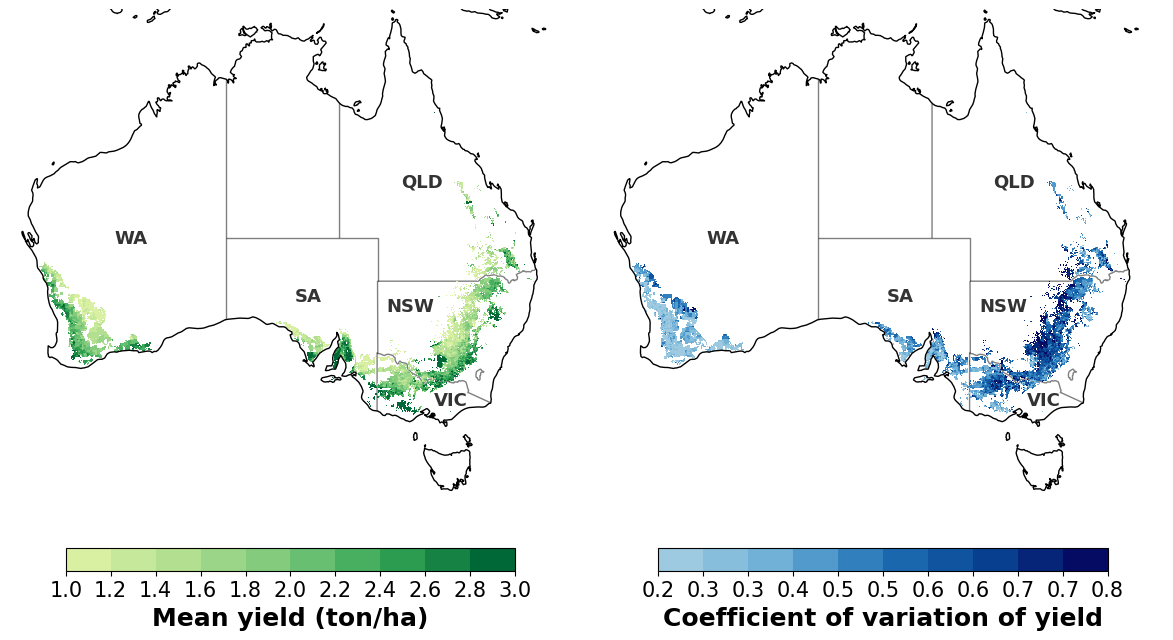

In [9]:
import xarray as xr
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ── Load data ────────────────────────────────────────────────────────────────
yield_summary_path = datadir + 'ag_data/'
avg_yield = xr.open_dataset(yield_summary_path + 'avg_yield.nc')
std_yield = xr.open_dataset(yield_summary_path + 'std_yield.nc')

# ── Compute coefficient of variation ─────────────────────────────────────────
cv = std_yield.y_wheat / avg_yield.y_wheat

# ── Helper: sort, reindex, mask ───────────────────────────────────────────────
def prepare_da(da):
    da = da.sortby('lat').sortby('lon')
    lat_res = round(float(da.lat.diff('lat').median()), 4)
    lon_res = round(float(da.lon.diff('lon').median()), 4)
    lat_full = np.arange(float(da.lat.min()), float(da.lat.max()) + lat_res / 2, lat_res)
    lon_full = np.arange(float(da.lon.min()), float(da.lon.max()) + lon_res / 2, lon_res)
    da = da.reindex(lat=lat_full, lon=lon_full, method='nearest', tolerance=lat_res)
    return da

da_avg = prepare_da(avg_yield.y_wheat)
da_cv  = prepare_da(cv)

# ── Wheatbelt outline (drawn behind everything, white edge) ──────────────────
wheatbelt_shp_path = '/g/data/w97/mg5624/ABS_project/ag_data/wheatbelt_shapefiles/wheatbelt.shp'
wheatbelt_shp = gpd.read_file(wheatbelt_shp_path)

# ── State label positions ─────────────────────────────────────────────────────
STATE_LABELS = {
    'WA':  (121.5, -26.0),
    'SA':  (135.5, -30.0),
    'QLD': (144.5, -22.0),
    'NSW': (143.6, -30.7),
    'VIC': (146.8, -37.3),
}

# scale matched to '50m' used in the growing-season plots
states_provinces = cfeature.NaturalEarthFeature(
    'cultural', 'admin_1_states_provinces_lines', '50m',
    edgecolor='black', facecolor='none', alpha=0.5
)

def add_map_features(ax):
    wheatbelt_shp.plot(ax=ax, facecolor='none', edgecolor='white', linewidth=0.8, zorder=1)
    ax.add_feature(cfeature.OCEAN, zorder=100, facecolor='white', edgecolor='k')
    ax.add_feature(states_provinces, linestyle='-', linewidth=1)
    ax.spines['geo'].set_visible(False)

    # Bold state labels
    for state, (lon, lat) in STATE_LABELS.items():
        ax.text(
            lon, lat, state,
            transform=ccrs.PlateCarree(),
            fontsize=13, fontweight='bold',
            color='#333333',
            ha='center', va='center',
            zorder=5
        )

# All-greens colormap — starts at a visible light green, ends deep forest
AGRI_COLORS   = [ '#d9f0a3', '#addd8e', '#78c679', '#31a354', '#006837']  # yellow → deep green
CV_COLORS     = [ '#9ecae1', '#6baed6', '#2171b5', '#084594', "#050B63"]  # light → deep blue

def plot_panel(ax, da, label, title, cmap, n_bins=10, vmin=None, vmax=None):
    data = np.ma.masked_invalid(da.values)
    vals = da.values[~np.isnan(da.values)]

    if vmin is None:
        vmin = np.round(float(np.percentile(vals, 5)), 1)
    if vmax is None:
        vmax = np.round(float(np.percentile(vals, 95)), 1)

    cmap = mcolors.LinearSegmentedColormap.from_list('agri', cmap, N=n_bins)
    cmap.set_bad(color='none')

    bounds = np.linspace(vmin, vmax, n_bins + 1)
    norm   = mcolors.BoundaryNorm(bounds, ncolors=n_bins)

    mesh = ax.pcolormesh(
        da.lon.values, da.lat.values, data,
        cmap=cmap, norm=norm,
        transform=ccrs.PlateCarree(),
        zorder=4, shading='auto'
    )

    cbar = plt.colorbar(
        mesh, ax=ax, orientation='horizontal',
        fraction=0.04, pad=0.08, shrink=0.9,
        ticks=bounds
    )
    cbar.set_label(label, fontsize=18, fontweight='bold')
    cbar.ax.tick_params(labelsize=15)
    cbar.ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))

    # ax.set_title(title, fontsize=20, fontweight='bold', pad=10)

# ── Figure ────────────────────────────────────────────────────────────────────
ncols = 2
nrows = 1
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(6 * ncols, 6.5 * nrows),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for ax in axes:
    add_map_features(ax)

plot_panel(
    axes[0], da_avg,
    label='Mean yield (ton/ha)',
    title='Mean wheat yield (2000–2020)',
    cmap=AGRI_COLORS,
    vmin=1,
    vmax=3
)

plot_panel(
    axes[1], da_cv,
    label='Coefficient of variation of yield',
    title='Yield variability (CV) (2000–2020)',
    cmap=CV_COLORS,
    vmin=0.25,
    vmax=0.75
)

plt.tight_layout()
plt.show()

In [10]:
agcd_datadir = '/g/data/zv2/agcd/v1-0-1/precip/total/r005/01day/'
grid = xr.open_dataset(agcd_datadir + 'agcd_v1-0-1_precip_total_r005_daily_2016.nc').precip.isel(time=-50)
grid = grid.reset_coords(drop=True)


def load_crop_growing_season_and_regrid(crop, target_grid):
    crop_calendar_path = f'{datadir}crop_calendar/{crop}.crop.calendar.nc'
    crop_calendar = xr.open_dataset(crop_calendar_path)
    
    crop_calendar = crop_calendar.sel(latitude=slice(-7, -45), longitude=slice(110, 155))
    crop_calendar = crop_calendar.rename({'latitude': 'lat', 'longitude': 'lon'})
    crop_calendar = crop_calendar.interp_like(target_grid, method='nearest')
    # Fill in missing values
    crop_calendar_filled = crop_calendar.interpolate_na(dim='lat', method='nearest', fill_value='extrapolate')
    crop_calendar_filled = crop_calendar_filled.interpolate_na(dim='lon', method='nearest', fill_value='extrapolate')
    crop_calendar_ls_mask = crop_calendar_filled.where(~np.isnan(target_grid))
    return crop_calendar_ls_mask

crop_calendar = load_crop_growing_season_and_regrid('Wheat', grid)


def distance_between_days(start_day, end_day, leap_year=False):
    wrap_around = start_day > end_day
    distance = xr.where(
        wrap_around,
        (365 - start_day + 1) + end_day,  # e.g., Dec 31 (365) to Jan 1 (1) is 2 days
        end_day - start_day + 1
    )

    # Adjust for leap year: add 1 if day 60 (Feb 29) is in the range
    if leap_year:
        # Check if 60 falls between start and end, considering wrap
        contains_60 = xr.where(
            wrap_around,
            (start_day <= 60) | (end_day >= 60),
            (start_day <= 60) & (end_day >= 60)
        )
        distance += contains_60.astype(int)
    return distance

/scratch/w97/mg5624/tmp/ipykernel_1219353/3563929309.py:8: FutureWarning: In a future version, xarray will not decode the variable 'harvest.range' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  crop_calendar = xr.open_dataset(crop_calendar_path)
/scratch/w97/mg5624/tmp/ipykernel_1219353/3563929309.py:8: FutureWarning: In a future version, xarray will not decode the variable 'plant.range' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which 

In [11]:
def len_of_season(crop_calendar, season):
    """
    Finds length of season across Australia.

    Args:
    crop_calendar (xr.Dataset): crop calendar for crop in question
        season (str): season to find length of ('growing', 'planting', 'mid', 'harvest')
    """
    start_of_season = crop_calendar['plant']
    season_len = distance_between_days(
        start_of_season,
        crop_calendar['harvest']
    )
    if season == 'growing':
        return season_len
    
    tercile_len = np.floor(season_len / 3)
    # start_of_season = crop_calendar['plant.start']
    start_of_mid = start_of_season + tercile_len + 1
    if season == 'planting':
        season_len = distance_between_days(start_of_season, start_of_mid)
        return season_len
    start_of_harvest = start_of_season + (2 * tercile_len) + 1
    if season == 'mid':
        season_len = distance_between_days(start_of_mid, start_of_harvest)
        return season_len
    if season == 'harvest':
        end_of_season = crop_calendar['harvest']
        season_len = distance_between_days(start_of_harvest, end_of_season)
        return season_len
    print(f'Season: {season}, not appropriate name for season')

In [12]:
def load_average_vars_over_growing_season(vars, timeperiod=['2000', '2020'], agg='mean', seasons=['growing'], replace=False):
    """
    Load and preprocess all variables for the given time period and seasons.
    Returns a dict of {var: averaged Dataset}.
    """
    wheatbelt_path = '/g/data/w97/mg5624/ABS_project/ag_data/wheatbelt_shapefiles/wheatbelt.nc'
    # wheatbelt_shp_path = '/g/data/w97/mg5624/RF_project/wheat_belt/Wheatbelt_SA2/Agriculture_Wheatbelt_one_polygon.shp'
    wheatbelt_shp_path = '/g/data/w97/mg5624/ABS_project/ag_data/wheatbelt_shapefiles/wheatbelt.shp'
    climate_datadir = datadir + 'extremes/FY_aggregated/'

    grid = xr.open_dataset(f'{climate_datadir}precip_FY_agg.nc').growing_seas_precip_mean
    wheatbelt_mask = regrid_mask(xr.open_dataarray(wheatbelt_path).astype(bool), grid)
    crop_calendar = load_crop_growing_season_and_regrid('Wheat', grid)
    wheatbelt_shp = gpd.read_file(wheatbelt_shp_path)

    drought_heatwave_frost_vars = {'180_day_precip_drought', '180_day_soil_moisture_drought', 'heatwave', 'frost'}
    
    # Precompute season lengths for all requested seasons
    seas_lens = {seas: len_of_season(crop_calendar, seas) for seas in seasons}

    var_agg = {
        'tmax': 'mean', 'tmin': 'mean', 'tavg': 'mean',
        'precip': 'mean',
        '180_day_precip_drought': 'sum',
        '180_day_precip_drought_intensity': 'mean',
        '180_day_soil_moisture_drought': 'sum',
        '180_day_soil_moisture_drought_intensity': 'mean',
        'heatwave': 'sum',
        'heatwave_intensity': 'mean',
        'frost': 'sum',
    }

    loaded = {}
    for var in vars:
        print(var)
        
        # Load the full dataset once per var (only if needed)
        data = None
        var_data = {}
        
        for seas in seasons:
            agg_data_path = f'{climate_datadir}{var}_{seas}_{agg}_{timeperiod[0]}-{timeperiod[1]}.nc'
            
            if os.path.exists(agg_data_path) and not replace:
                var_data[seas] = xr.open_dataarray(agg_data_path)
            else:
                # Lazy-load the full dataset only when first needed
                if data is None:
                    data_path = f'{climate_datadir}{var}_FY_agg_1950-2021.nc'
                    data = (
                        xr.open_dataset(data_path)
                        .where(wheatbelt_mask)
                        .sel(time=slice(timeperiod[0], timeperiod[1]))
                    )
                
                seas_data = data[f'{seas}_seas_{var}_{var_agg[var]}']
                if var in drought_heatwave_frost_vars:
                    seas_data = (seas_data / seas_lens[seas]) * 100
                
                if agg == 'mean':
                    seas_data = seas_data.mean(dim='time')
                elif agg == 'std':
                    seas_data = seas_data.std(dim='time')
                elif agg == 'cov':
                    mean_data = seas_data.mean(dim='time')
                    std_data = seas_data.std(dim='time')
                    seas_data = (std_data / mean_data) * 100
                seas_data.to_netcdf(agg_data_path)
                var_data[seas] = seas_data
        
        loaded[var] = var_data

    return loaded, wheatbelt_shp


def add_state_labels(ax):
    for state, (lon, lat) in STATE_LABELS.items():
        ax.text(
            lon, lat, state,
            transform=ccrs.PlateCarree(),
            fontsize=13, fontweight='bold',
            color='#333333',
            ha='center', va='center',
            zorder=5
        )

def plot_average_vars_over_growing_season(loaded_data, wheatbelt_shp, vars, timeperiod=['2000', '2020'], seasons=['growing'], vmin=None, vmax=None):
    """
    Plot preloaded variables in a single figure (max 2 columns). Call load_average_vars_over_growing_season() first.
    """
    season_names = {
        'planting': 'Early Season', 'mid': 'Mid Season',
        'harvest': 'Late Season', 'growing': 'Growing Season',
    }
    var_labels = {
        'tmax': 'Maximum daily temperature',
        'tmin': 'Minimum daily temperature',
        'tavg': 'Average daily temperature',
        'precip': 'Precipitation',
        '180_day_precip_drought': 'Precipitation drought days (%)',
        '180_day_precip_drought_intensity': 'Precipitation drought intensity (%)',
        '180_day_soil_moisture_drought': 'Soil moisture drought days (%)',
        '180_day_soil_moisture_drought_intensity': 'Soil moisture drought intensity (%)',
        'heatwave': 'Heatwave days (%)',
        'heatwave_intensity': 'Heatwave intensity (%)',
        'frost': 'Frost days (%)',
    }
    # units only needed for temp + precip vars
    var_units = {
        'tmax': '°C', 'tmin': '°C', 'tavg': '°C',
        'precip': r'mm day$^{-1}$',
    }
    var_cmaps = {
        'tmax': 'YlOrRd', 'tmin': 'YlOrRd', 'tavg': 'YlOrRd',
        'precip': 'Blues',
        '180_day_precip_drought': 'YlOrBr',
        '180_day_precip_drought_intensity': 'YlOrBr',
        '180_day_soil_moisture_drought': 'YlOrBr',
        '180_day_soil_moisture_drought_intensity': 'YlOrBr',
        'heatwave': 'Reds', 'heatwave_intensity': 'Reds',
        'frost': 'Blues_r',
    }
    # number of discrete bins per variable (defaults to 10 if not listed)
    var_nbins = {
        'tmax': 12, 'tmin': 12, 'tavg': 12,
        'precip': 10,
    }

    var_levels = {
        'precip': np.round(np.arange(0.8, 2.2 + 1e-9, 0.2), 2),
        'tmin': np.round(np.arange(6.0, 9.5 + 1e-9, 0.5), 2),
        'tmax': np.round(np.arange(17, 24 + 1e-9, 1), 2),
    }

    # Build shared map features once
    states_provinces = NaturalEarthFeature(
        category='cultural', name='admin_1_states_provinces_lines',
        scale='50m', edgecolor='black', facecolor='none', alpha=0.5
    )

    # --- Build list of (var, seas) panels to plot ---
    panels = [(var, seas) for var in vars for seas in seasons]
    n_panels = len(panels)

    ncols = 3 if n_panels > 2 else 2 if n_panels > 1 else 1
    nrows = int(np.ceil(n_panels / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(6 * ncols, 6.5 * nrows),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    # normalize axes to a flat array regardless of nrows/ncols
    axes = np.atleast_1d(axes).flatten()

    for idx, (var, seas) in enumerate(panels):
        ax = axes[idx]
        print(f'{var} over {seas} season for {timeperiod}')
        avg_da = loaded_data[var][seas]
        season_label = season_names.get(seas, seas)
        var_label = var_labels.get(var, var)
        units = var_units.get(var, '')
        cbar_label = f"{var_label} ({units})" if units else var_label

        if var in var_levels:
            levels = var_levels[var]
            vmin_cbar = levels[0]
            vmax_cbar = levels[-1]
            plot_levels = levels
            cbar_ticks = levels
        else:
            nbins = var_nbins.get(var, 10)
            if vmin is None or vmax is None:
                vmin_cbar, vmax_cbar = np.nanpercentile(avg_da.values, [5, 95])
            else:
                vmin_cbar = vmin
                vmax_cbar = vmax
            plot_levels = nbins
            cbar_ticks = None

        p = avg_da.plot(
            ax=ax,
            cmap=var_cmaps.get(var, 'viridis'),
            vmin=vmin_cbar,
            vmax=vmax_cbar,
            levels=plot_levels,
            add_colorbar=False,  # build manually below for bold-label styling
        )

        cbar = plt.colorbar(
            p, ax=ax, orientation='horizontal',
            fraction=0.04, pad=0.08, shrink=0.9,
        )
        cbar.set_label(cbar_label, fontsize=18, fontweight='bold')
        cbar.ax.tick_params(labelsize=15)
        cbar.ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))

        # ax.set_title(f"Average {season_label}\n{var_label} ({timeperiod[0]}–{timeperiod[1]})", fontsize=13)
        ax.add_feature(cfeature.OCEAN, zorder=100, facecolor='white', edgecolor='k')
        ax.add_feature(states_provinces, linestyle='-', linewidth=1)
        ax.spines['geo'].set_visible(False)
        wheatbelt_shp.plot(ax=ax, facecolor='none', edgecolor='k', linewidth=0.8)

        add_state_labels(ax)

    # turn off any unused axes (e.g. odd number of panels with 2 columns)
    for ax in axes[n_panels:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [13]:
var_data, wheatbelt_shp = load_average_vars_over_growing_season(mean_vars, timeperiod=['1970', '2020'], seasons=['growing'], replace=False)

/scratch/w97/mg5624/tmp/ipykernel_1219353/3563929309.py:8: FutureWarning: In a future version, xarray will not decode the variable 'harvest.range' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  crop_calendar = xr.open_dataset(crop_calendar_path)
/scratch/w97/mg5624/tmp/ipykernel_1219353/3563929309.py:8: FutureWarning: In a future version, xarray will not decode the variable 'plant.range' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which 

tmax
tmin
precip


precip over growing season for ['1970', '2020']
tmin over growing season for ['1970', '2020']
tmax over growing season for ['1970', '2020']


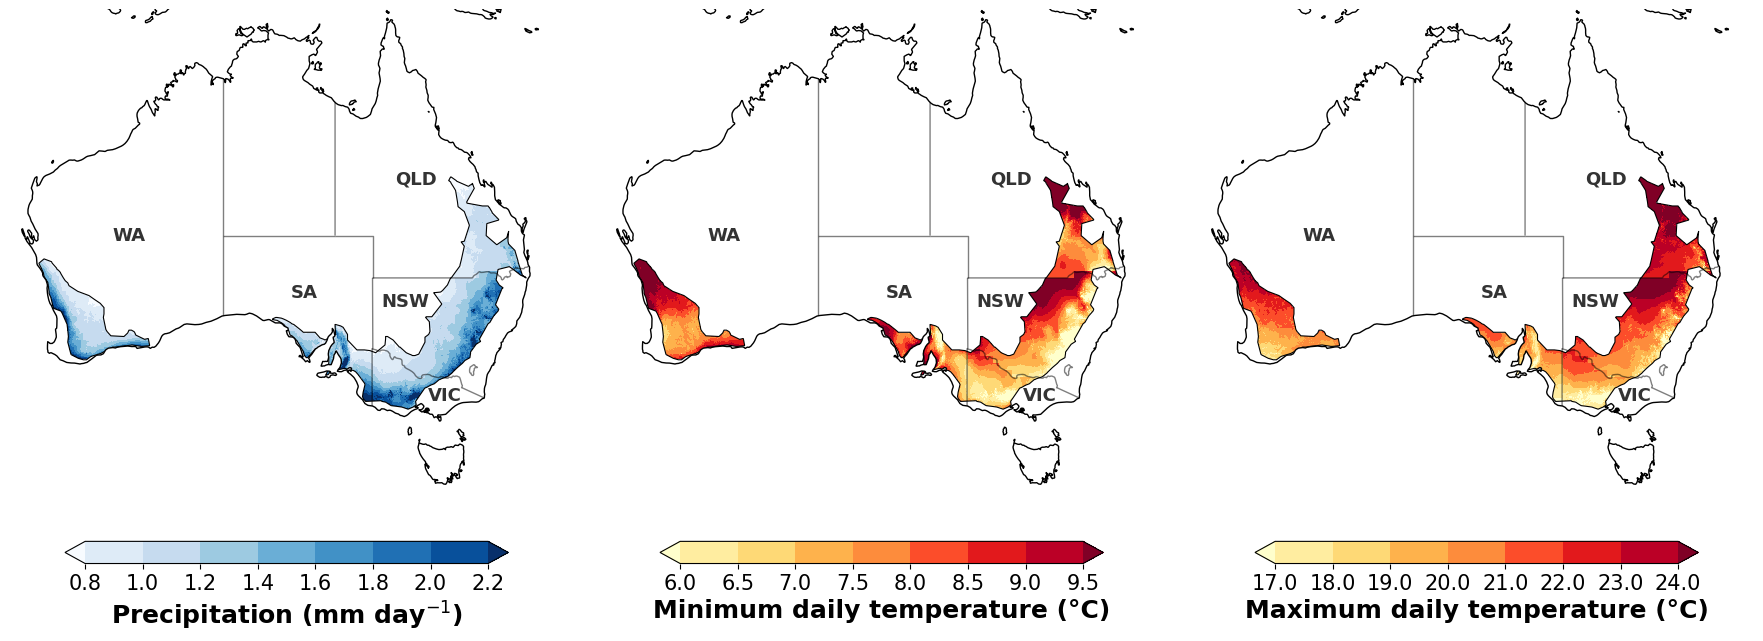

In [14]:
# precip_vars = ['precip']
avg_vars = ['precip', 'tmin', 'tmax']
plot_average_vars_over_growing_season(var_data, wheatbelt_shp, avg_vars, timeperiod=['1970', '2020'], seasons=['growing'], vmin=None, vmax=None)

## Growing Season Dates

In [15]:
agcd_datadir = '/g/data/zv2/agcd/v1-0-1/precip/total/r005/01day/'
grid = xr.open_dataset(agcd_datadir + 'agcd_v1-0-1_precip_total_r005_daily_2016.nc').precip.isel(time=-50)
grid = grid.reset_coords(drop=True)


def load_crop_growing_season_and_regrid(crop, target_grid):
    crop_calendar_path = f'{datadir}crop_calendar/{crop}.crop.calendar.nc'
    crop_calendar = xr.open_dataset(crop_calendar_path)
    
    crop_calendar = crop_calendar.sel(latitude=slice(-7, -45), longitude=slice(110, 155))
    crop_calendar = crop_calendar.rename({'latitude': 'lat', 'longitude': 'lon'})
    crop_calendar = crop_calendar.interp_like(target_grid, method='nearest')
    # Fill in missing values
    crop_calendar_filled = crop_calendar.interpolate_na(dim='lat', method='nearest', fill_value='extrapolate')
    crop_calendar_filled = crop_calendar_filled.interpolate_na(dim='lon', method='nearest', fill_value='extrapolate')
    crop_calendar_ls_mask = crop_calendar_filled.where(~np.isnan(target_grid))
    return crop_calendar_ls_mask

crop_calendar = load_crop_growing_season_and_regrid('Wheat', grid)

/scratch/w97/mg5624/tmp/ipykernel_1219353/2209699474.py:8: FutureWarning: In a future version, xarray will not decode the variable 'harvest.range' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  crop_calendar = xr.open_dataset(crop_calendar_path)
/scratch/w97/mg5624/tmp/ipykernel_1219353/2209699474.py:8: FutureWarning: In a future version, xarray will not decode the variable 'plant.range' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which 

In [16]:
def distance_between_days(start_day, end_day, leap_year=False):
    wrap_around = start_day > end_day
    distance = xr.where(
        wrap_around,
        (365 - start_day + 1) + end_day,  # e.g., Dec 31 (365) to Jan 1 (1) is 2 days
        end_day - start_day + 1
    )

    # Adjust for leap year: add 1 if day 60 (Feb 29) is in the range
    if leap_year:
        # Check if 60 falls between start and end, considering wrap
        contains_60 = xr.where(
            wrap_around,
            (start_day <= 60) | (end_day >= 60),
            (start_day <= 60) & (end_day >= 60)
        )
        distance += contains_60.astype(int)
    return distance

def growing_season_tercile_dates(crop_calendar):

    # start_of_season = circular_midpoint(
    #     crop_calendar['plant.start'],
    #     crop_calendar['plant']
    # )
    start_of_season = crop_calendar['plant']
    mean_season_len = distance_between_days(
        start_of_season,
        crop_calendar['harvest']
    )
    tercile_len = np.floor(mean_season_len / 3)
    print(tercile_len.sel(lat=-37, lon=143, method='nearest').values)
    # start_of_season = crop_calendar['plant.start']
    start_of_mid = start_of_season + tercile_len + 1
    start_of_harvest = start_of_season + (2 * tercile_len) + 1
    end_of_season = crop_calendar['harvest']

    start_of_mid = xr.where(
        start_of_mid >= 366, start_of_mid - 365, start_of_mid
    )

    start_of_harvest = xr.where(
        start_of_harvest >= 366, start_of_harvest - 365, start_of_harvest
    )

    # Convert 0 to 365 for DOY convention
    end_of_season = xr.where(
        end_of_season < 1, 365, end_of_season
    )

    start_of_harvest = xr.where(
        start_of_harvest < 1, 365, start_of_harvest
    )

    start_of_season = xr.where(
        start_of_season < 1, 365, start_of_season
    )

    start_of_mid = xr.where(
        start_of_mid < 1, 365, start_of_mid
    )
    
    return start_of_season, start_of_mid, start_of_harvest, end_of_season

season_dates = growing_season_tercile_dates(crop_calendar)

66.0


In [17]:
state_points = {
    "NSW":  (-33.0, 147.0),
    "VIC":  (-36.5, 145.0),
    "QLD":  (-24.0, 148.0),
    "SA":   (-34.0, 138.0),
    "WA":   (-31.0, 118.0),
}

import datetime as dt

def doy_to_date(doy):
    return dt.datetime(2001, 1, 1) + pd.Timedelta(days=doy - 1)

def extract_value(da, lat, lon):
    return da.sel(lat=lat, lon=lon, method="nearest").item()

rows = []
start_season, start_mid, start_harv, end_season = season_dates
for state, (lat, lon) in state_points.items():
    rows.append({
        "state": state,
        "start_gs": extract_value(start_season, lat, lon),
        "start_mid": extract_value(start_mid, lat, lon),
        "start_harv": extract_value(start_harv, lat, lon),
        "end": extract_value(end_season, lat, lon),
    })

df = pd.DataFrame(rows)

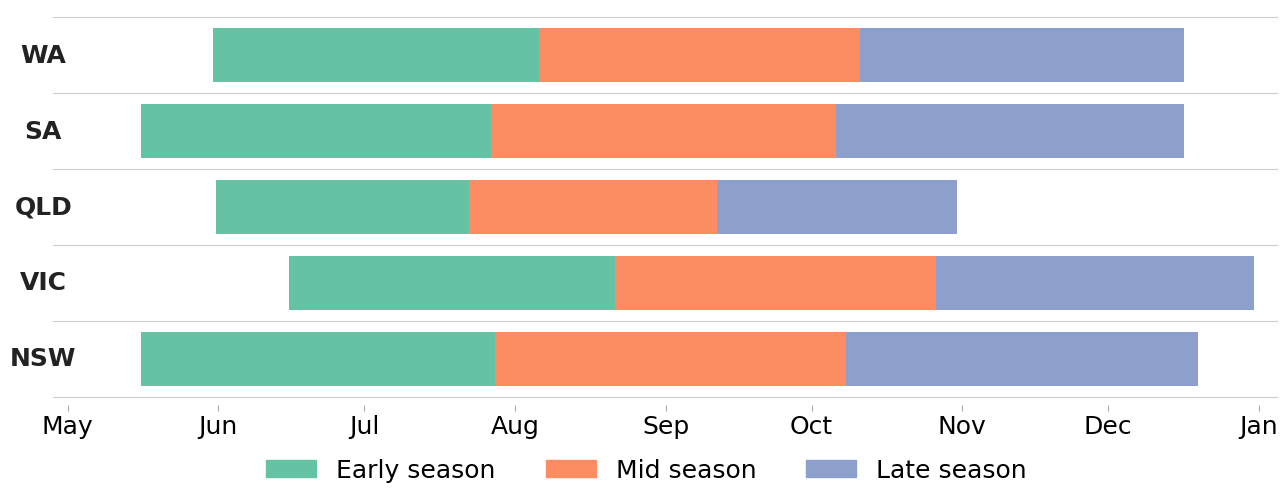

In [18]:
import datetime as dt
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# ── Color palette (original) ──────────────────────────────────────────────────
colors = {
    "early":   "#66c2a5",
    "mid":     "#fc8d62",
    "harvest": "#8da0cb",
}

LABEL_MAP = {
    "early":   "Early season",
    "mid":     "Mid season",
    "harvest": "Late season",
}

def doy_to_date(doy):
    return dt.datetime(2001, 1, 1) + pd.Timedelta(days=doy - 1)

def plot_segment(ax, y, start_doy, end_doy, color, label=None, height=0.7):
    start      = doy_to_date(start_doy)
    end        = doy_to_date(end_doy)
    year_end   = dt.datetime(2001, 12, 31)
    year_start = dt.datetime(2001, 1, 1)
    kwargs = dict(color=color, label=label, height=height,
                  linewidth=0, align='center')
    if end_doy >= start_doy:
        ax.barh(y, end - start, left=start, **kwargs)
    else:
        ax.barh(y, year_end - start, left=start, **kwargs)
        ax.barh(y, end - year_start, left=year_start, **{**kwargs, 'label': None})

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

n_states = len(df)

# ── Plot bars ─────────────────────────────────────────────────────────────────
for i, row in df.iterrows():
    plot_segment(ax, i, row.start_gs,   row.start_mid,  colors["early"],
                 label="Early season" if i == 0 else None)
    plot_segment(ax, i, row.start_mid,  row.start_harv, colors["mid"],
                 label="Mid season"   if i == 0 else None)
    plot_segment(ax, i, row.start_harv, row.end,        colors["harvest"],
                 label="Late season"  if i == 0 else None)

    # State label
    ax.text(
        dt.datetime(2001, 4, 26), i, row.state,
        ha='center', va='center',
        fontsize=18, fontweight='bold', color='#222222'
    )

# ── Horizontal divider lines between states ───────────────────────────────────
for i in range(n_states + 1):
    ax.axhline(i - 0.5, color='#cccccc', linewidth=0.8, zorder=1)

# ── X axis ────────────────────────────────────────────────────────────────────
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_xlim(dt.datetime(2001, 4, 28), dt.datetime(2002, 1, 5))
ax.tick_params(axis='x', labelsize=18, length=4, color='#aaaaaa')

# ── Y axis — hide ─────────────────────────────────────────────────────────────
ax.set_yticks([])
ax.set_ylim(-0.6, n_states - 0.4)

# ── Remove spines ─────────────────────────────────────────────────────────────
for spine in ax.spines.values():
    spine.set_visible(False)

# ── Title & legend ────────────────────────────────────────────────────────────

ax.set_xlabel("")  # remove Month label

# legend at very bottom, outside axes
patches = [mpatches.Patch(color=colors[k], label=LABEL_MAP[k]) for k in colors]
fig.legend(
    handles=patches,
    loc='lower center',
    fontsize=18,
    frameon=False,
    ncol=3,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)  # make room for legend below
plt.show()

## Influence of Extremes

In [19]:
perf_datadir = f'{datadir}/yield_model_analytics/performance_scores/'
states = ["AUS", "NSW", "VIC", "QLD", "SA", "WA"]
results = []

for var in ['all_temp_and_hyd', 'extremes_only', 'clim_only', 'drought_only', 'temp_extremes_only']:
    for state in states:
        filepath = f'{perf_datadir}/state_aggregated/{var}/full_season_only/'
        # if var not in ['clim_only', 'temp_extremes_only']:
        #     filepath = filepath + 'single_drought_180/'
        filename = f'RandomForestRegressor_{state}_predicted_vs_true_yield_yearsplit_20agland_norm.csv'

        df = pd.read_csv(
            filepath + filename
        )
        
        # Compute Pearson r² for each seed
        r2_by_seed = (
            df.groupby("seed")
            .apply(lambda g: g["True"].corr(g["Predicted"]) ** 2)
            .reset_index(name="r2")
        )
        
        r2_by_seed["state"] = state
        r2_by_seed['variables'] = var
        results.append(r2_by_seed)

# Combine all states
r2_df = pd.concat(results, ignore_index=True)
r2_df

/scratch/w97/mg5624/tmp/ipykernel_1219353/631380819.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["True"].corr(g["Predicted"]) ** 2)
/scratch/w97/mg5624/tmp/ipykernel_1219353/631380819.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["True"].corr(g["Predicted"]) ** 2)
/scratch/w97/mg5624/tmp/ipykernel_1219353/631380819.py:19: FutureWarning: DataFrameGroupBy.apply opera

/scratch/w97/mg5624/tmp/ipykernel_1219353/631380819.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["True"].corr(g["Predicted"]) ** 2)
/scratch/w97/mg5624/tmp/ipykernel_1219353/631380819.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["True"].corr(g["Predicted"]) ** 2)
/scratch/w97/mg5624/tmp/ipykernel_1219353/631380819.py:19: FutureWarning: DataFrameGroupBy.apply opera

,seed,r2,state,variables
0,0,0.694237,AUS,all_temp_and_hyd
1,1,0.691580,AUS,all_temp_and_hyd
2,2,0.691356,AUS,all_temp_and_hyd
3,3,0.692717,AUS,all_temp_and_hyd
4,4,0.691394,AUS,all_temp_and_hyd
...,...,...,...,...
295,5,0.020861,WA,temp_extremes_only
296,6,0.021127,WA,temp_extremes_only
297,7,0.019536,WA,temp_extremes_only
298,8,0.018623,WA,temp_extremes_only


In [20]:
r2_df.groupby(['variables','state'])['r2'].agg(['median']).reset_index()

,variables,state,median
0,all_temp_and_hyd,AUS,0.691519
1,all_temp_and_hyd,NSW,0.696833
2,all_temp_and_hyd,QLD,0.515957
3,all_temp_and_hyd,SA,0.585223
4,all_temp_and_hyd,VIC,0.684044
5,all_temp_and_hyd,WA,0.591179
6,clim_only,AUS,0.522100
7,clim_only,NSW,0.494920
8,clim_only,QLD,0.314271
9,clim_only,SA,0.396888


variables  all_temp_and_hyd  clim_only  extremes_only  drought_only  \
state                                                                 
NSW                0.696833   0.494920       0.622267      0.581555   
VIC                0.684044   0.189270       0.740742      0.768045   
QLD                0.515957   0.314271       0.533809      0.427630   
SA                 0.585223   0.396888       0.579643      0.545249   
WA                 0.591179   0.263904       0.668278      0.707356   

variables  temp_extremes_only  
state                          
NSW                  0.118941  
VIC                  0.331329  
QLD                  0.130474  
SA                   0.125627  
WA                   0.019329  


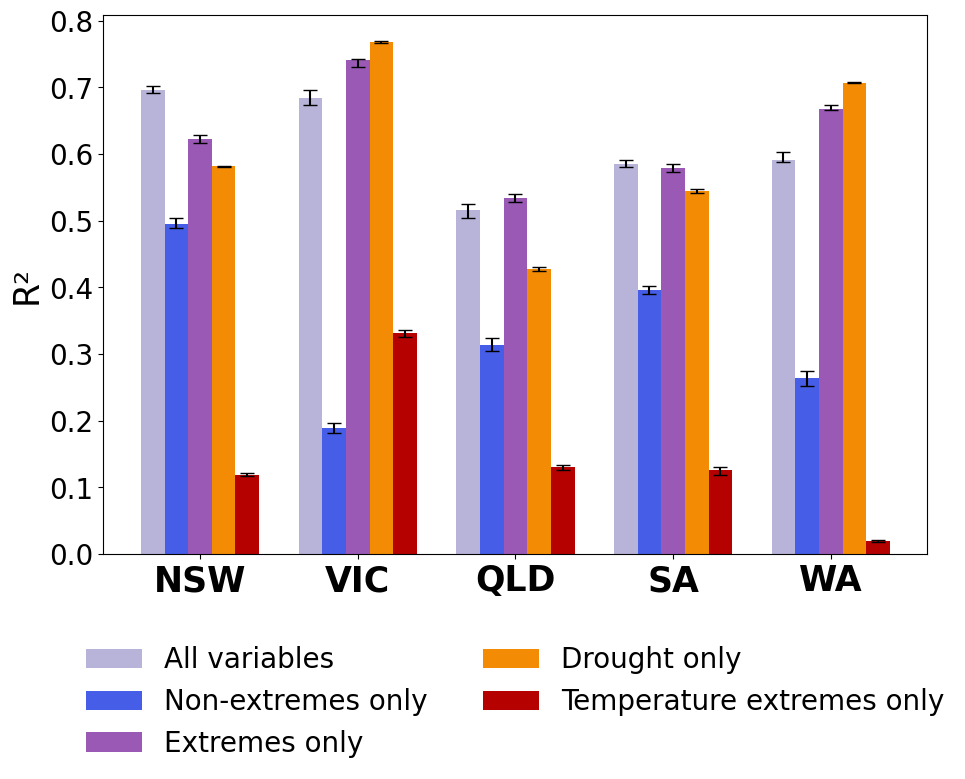

In [21]:
summary = (
    r2_df.groupby(["state", "variables"])["r2"]
         .agg(["median", "min", "max"])
         .reset_index()
)

summary["lower"] = summary["median"] - summary["min"]
summary["upper"] = summary["max"] - summary["median"]

pivot_median = summary.pivot(index="state", columns="variables", values="median")
pivot_lower  = summary.pivot(index="state", columns="variables", values="lower")
pivot_upper  = summary.pivot(index="state", columns="variables", values="upper")

state_order = ["NSW", "VIC", "QLD", "SA", "WA"]

pivot_median = pivot_median.reindex(state_order)
pivot_lower  = pivot_lower.reindex(state_order)
pivot_upper  = pivot_upper.reindex(state_order)

color_map = {
    "clim_only":   "#465EE7",  # blue
    "extremes_only":      "#9B59B6",  # purple
    "all_temp_and_hyd":          "#B8B4D9",
    # "drought_only":       "#D4A017",  # gold/mustard (was orange)
    # "temp_extremes_only": "#C2200E"
    "temp_extremes_only":                 "#B60101",
    "drought_only": "#F38B04",
    # "drought_only":       "#E28101",  # orange
    # "temp_extremes_only": "#C2200E",  # red
}

# color_map = {
#     "No. of 180 day precip drought days": "#E28101",  # light golden
#     "180 day precip drought intensity":   "#EEBC32",  # amber
#     "No. of heatwave days":               "#EC9C91",  # light red
#     "heatwave intensity":                 "#C2200E",  # deep red
#     "precip mean":                        "#465EE7",  # blue
# }

order = [
    "all_temp_and_hyd",
    "clim_only",
    "extremes_only",
    "drought_only",
    "temp_extremes_only"
]

# Reindex pivot tables to enforce bar order
pivot_median = pivot_median[order]
pivot_lower  = pivot_lower[order]
pivot_upper  = pivot_upper[order]

print(pivot_median)
states = pivot_median.index
vars_list = pivot_median.columns

x = np.arange(len(states))
width = 0.15

plt.figure(figsize=(10,8))

var_dict = {
    'all_temp_and_hyd': 'All variables',
    'extremes_only': 'Extremes only',
    'clim_only': 'Non-extremes only',
    'drought_only': 'Drought only',
    'temp_extremes_only': 'Temperature extremes only',
}

# Plot bars
for i, var in enumerate(vars_list):
    plt.bar(
        x + (i - len(vars_list)/2) * width + width/2,   # centered bars
        pivot_median[var],
        width=width,
        label=var_dict[var],
        yerr=[pivot_lower[var], pivot_upper[var]],
        capsize=5,
        color=color_map[var],
    )

# Center xticks under the grouped bars
plt.xticks(x, states, fontsize=25, fontweight="bold")

plt.ylabel("R²", fontsize=25)
plt.yticks(fontsize=20)

# Legend outside the axes (right side)
plt.legend(
    fontsize=20,
    bbox_to_anchor=(0.5, -0.15),
    loc="upper center",
    ncol=2,
    frameon=False,
    borderaxespad=0
)

plt.tight_layout()
plt.show()


In [22]:
states = ["NSW", "VIC", "QLD", "SA", "WA"]
summaries = {}
import_datadir = f'{datadir}/yield_model_analytics/variable_importance_scores/'
for state in states:
    df = pd.read_csv(f"{import_datadir}/all_vars/full_season/RandomForestRegressor_{state}_permutation_var_import_20agland_norm.csv")   # adjust filename pattern
    
    # Compute stats across seeds (rows)
    mean_imp = df.mean(axis=0)
    min_imp  = df.min(axis=0)
    max_imp  = df.max(axis=0)
    
    summary = pd.DataFrame({
        "mean": mean_imp,
        "min": min_imp,
        "max": max_imp
    })
    
    summary["lower"] = summary["mean"] - summary["min"]
    summary["upper"] = summary["max"] - summary["mean"]
    
    # Sort and keep top 10
    summary = summary.sort_values("mean", ascending=False).head(10)
    
    summaries[state] = summary
    print(summaries['NSW']['mean'])


growing_seas_180_day_precip_drought_sum                      0.106661
growing_seas_precip_mean                                     0.084643
growing_seas_heatwave_intensity_mean                         0.081046
growing_seas_180_day_precip_drought_intensity_mean           0.073536
growing_seas_consecutive_dry_days_max                        0.070582
growing_seas_temperature_range_mean                          0.061148
growing_seas_180_day_soil_moisture_drought_sum               0.038361
growing_seas_heatwave_sum                                    0.037832
growing_seas_soil_moisture_mean                              0.035393
growing_seas_180_day_soil_moisture_drought_intensity_mean    0.035152
Name: mean, dtype: float64
growing_seas_180_day_precip_drought_sum                      0.106661
growing_seas_precip_mean                                     0.084643
growing_seas_heatwave_intensity_mean                         0.081046
growing_seas_180_day_precip_drought_intensity_mean           0.

In [23]:
import re

def transform_name(name):
    stage_map = {
        'growing_seas': ''
    }
    # Pattern: stage_var_sum
    m = re.match(r'^(growing_seas)_(.+?)_(sum|intensity_mean|mean)$', name)
    if not m:
        return name  # leave unchanged if it doesn't match the pattern
    
    stage, var, suffix = m.groups()
    new_stage = stage_map[stage]
    var = var.replace('_', ' ')
    
    if suffix == 'sum':
        return f"{new_stage} No. of {var} days"
    elif suffix == 'intensity_mean':
        return f"{new_stage} {var} intensity"
    elif suffix == 'mean':
        return f"{new_stage} {var} mean"

In [24]:
states = ["NSW", "VIC", "QLD", "SA", "WA"]

top3_list = []

import_datadir = f'{datadir}/yield_model_analytics/variable_importance_scores/'
for state in states:
    df = pd.read_csv(f"{import_datadir}/all_vars/full_season/RandomForestRegressor_{state}_permutation_var_import_20agland_norm.csv")   # adjust filename pattern
    
    # Compute stats across seeds
    mean_imp = df.mean(axis=0)
    min_imp  = df.min(axis=0)
    max_imp  = df.max(axis=0)
    
    summary = pd.DataFrame({
        "predictor": mean_imp.index,
        "mean": mean_imp.values,
        "min": min_imp.values,
        "max": max_imp.values
    })
    
    summary["lower"] = summary["mean"] - summary["min"]
    summary["upper"] = summary["max"] - summary["mean"]
    summary["state"] = state
    
    # Select top 3 predictors
    summary = summary.sort_values("mean", ascending=False).head(3)
    
    top3_list.append(summary)

# Combine all states
top3 = pd.concat(top3_list, ignore_index=True)

In [25]:

top3['predictor'] = top3['predictor'].apply(transform_name)

In [26]:
# Sort within each state so bars go top → bottom
top3 = top3.sort_values(["state", "mean"], ascending=[True, False])

# --- Build y positions (your original logic preserved) ---
y_positions = {}
state_positions = {}
labels = []

y = 3 * len(states) + 3
for state in states:
    subset = top3[top3["state"] == state].sort_values("mean", ascending=False)
    n = len(subset)

    state_positions[state] = y + (n - 1) / 2 - 0.4

    for idx, row in subset.iterrows():
        y_positions[idx] = y
        labels.append(row["predictor"])
        y -= 1

    y -= 1.5

top3["y"] = top3.index.map(y_positions)
print(top3)


                              predictor      mean       min       max  \
0    No. of 180 day precip drought days  0.106661  0.093668  0.119968   
1                           precip mean  0.084643  0.076243  0.097002   
2                    heatwave intensity  0.081046  0.076628  0.083161   
6                    heatwave intensity  0.155221  0.145673  0.164032   
7    No. of 180 day precip drought days  0.116076  0.096090  0.128073   
8      180 day precip drought intensity  0.076822  0.063931  0.087581   
9    No. of 180 day precip drought days  0.157092  0.133382  0.169632   
10     180 day precip drought intensity  0.106445  0.088110  0.116847   
11                          precip mean  0.089916  0.085322  0.096277   
3    No. of 180 day precip drought days  0.142614  0.114599  0.157405   
4      180 day precip drought intensity  0.119897  0.108240  0.132573   
5                    heatwave intensity  0.089498  0.083753  0.094060   
12   No. of 180 day precip drought days  0.181504  

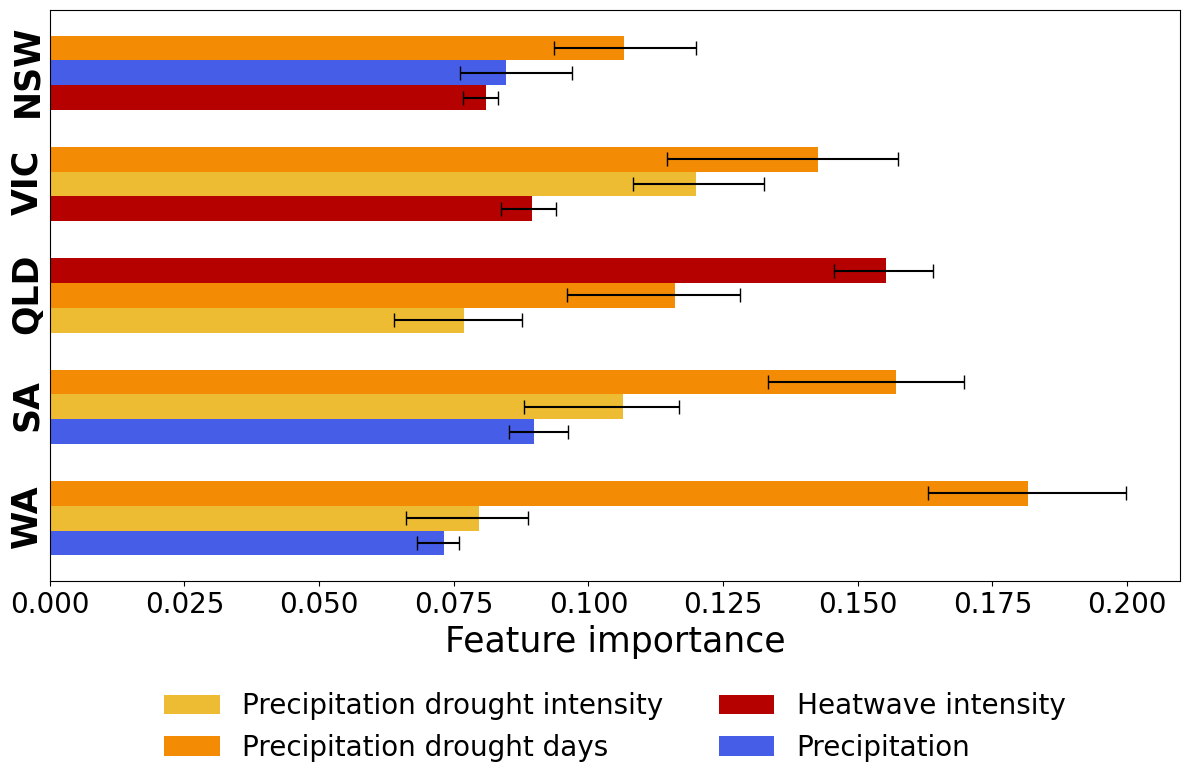

In [27]:
# --- Define fixed colors for the five variables (orange for drought) ---
var_import_color_map = {
    "No. of 180 day precip drought days": "#F38B04",  # light golden
    "180 day precip drought intensity":   "#EEBC32",  # amber
    "No. of heatwave days":               "#EC9C91",  # light red
    "heatwave intensity":                 "#B60101",  # deep red
    "precip mean":                        "#465EE7",  # blue
}

# var_import_color_map = {
#     "No. of 180 day precip drought days": "#B8860B",  # dark goldenrod
#     "180 day precip drought intensity":   "#F2C14E",  # pale butter yellow
#     "No. of heatwave days":               "#F2A6A0",  # soft coral-pink
#     "heatwave intensity":                 "#8B0000",  # dark maroon/red
#     "precip mean":                        "#465EE7",  # blue
# }

top3["predictor"] = top3["predictor"].str.strip()

# Assign colors to each row
top3["color"] = top3["predictor"].map(var_import_color_map)


plt.figure(figsize=(12, 8))
plt.barh(
    top3["y"],
    top3["mean"],
    xerr=[top3["lower"], top3["upper"]],
    capsize=5,
    color=top3["color"],
    height=1
    # edgecolor="black"
)

plt.xlabel("Feature importance", fontsize=25)
plt.xticks(fontsize=20)

# Remove predictor labels from y-axis
plt.yticks([])

ax = plt.gca()
xmin, xmax = ax.get_xlim()
x_label = xmin - 0.005 * (xmax - xmin)  # closer to bars than before
y_offset = -1.5  # tweak this if needed

# --- Add vertical state labels beside each 3-bar block ---
for state in states:
    plt.text(
        x_label,
        state_positions[state] + y_offset,  # slightly lower
        state,
        va="center",
        ha="right",
        fontsize=25,
        fontweight="bold",
        rotation=90,
        transform=ax.transData,
    )

# --- Legend below the plot ---
legend_items = (
    top3[["predictor", "color"]]
    .drop_duplicates()
    .sort_values("predictor")
)

# handles = [
#     plt.Line2D([0], [0], color=row["color"], lw=8)
#     for _, row in legend_items.iterrows()
# ]
from matplotlib.patches import Patch

handles = [
    Patch(facecolor=row["color"], edgecolor="none")
    for _, row in legend_items.iterrows()
]
labels_dict = {
    'No. of 180 day precip drought days': "Precipitation drought days",
    '180 day precip drought intensity': "Precipitation drought intensity",
    'No. of heatwave days': "Heatwave days",
    'heatwave intensity': "Heatwave intensity",
    'precip mean': "Precipitation"
}
labels = [labels_dict.get(label, label) for label in legend_items["predictor"].tolist()]

leg = plt.legend(
    handles,
    labels,
    # title="Variables",
    bbox_to_anchor=(0.5, -0.15),
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=20
)

plt.tight_layout()
plt.show()


## Timing of Extremes

In [28]:
states = ["AUS", "NSW", "VIC", "QLD", "SA", "WA"]

results = []

for stage in ['all_substages', 'planting_season_only', 'mid_season_only', 'harvest_season_only']:
    for state in states:
        df = pd.read_csv(
            f'{perf_datadir}/state_aggregated/extremes_only/{stage}/RandomForestRegressor_{state}_predicted_vs_true_yield_yearsplit_20agland_norm.csv'
        )
        
        # Compute Pearson r² for each seed
        r2_by_seed = (
            df.groupby("seed")
            .apply(lambda g: g["True"].corr(g["Predicted"]) ** 2)
            .reset_index(name="r2")
        )
        
        r2_by_seed["state"] = state
        r2_by_seed['stage'] = stage
        results.append(r2_by_seed)

# Combine all states
r2_df = pd.concat(results, ignore_index=True)
r2_df

/scratch/w97/mg5624/tmp/ipykernel_1219353/2382694998.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["True"].corr(g["Predicted"]) ** 2)
/scratch/w97/mg5624/tmp/ipykernel_1219353/2382694998.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["True"].corr(g["Predicted"]) ** 2)
/scratch/w97/mg5624/tmp/ipykernel_1219353/2382694998.py:14: FutureWarning: DataFrameGroupBy.apply op

/scratch/w97/mg5624/tmp/ipykernel_1219353/2382694998.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["True"].corr(g["Predicted"]) ** 2)
/scratch/w97/mg5624/tmp/ipykernel_1219353/2382694998.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["True"].corr(g["Predicted"]) ** 2)
/scratch/w97/mg5624/tmp/ipykernel_1219353/2382694998.py:14: FutureWarning: DataFrameGroupBy.apply op

,seed,r2,state,stage
0,0,0.686699,AUS,all_substages
1,1,0.691468,AUS,all_substages
2,2,0.696587,AUS,all_substages
3,3,0.697112,AUS,all_substages
4,4,0.692605,AUS,all_substages
...,...,...,...,...
235,5,0.636746,WA,harvest_season_only
236,6,0.635398,WA,harvest_season_only
237,7,0.632063,WA,harvest_season_only
238,8,0.634598,WA,harvest_season_only


In [29]:
summary = (
    r2_df.groupby(["stage", "state"])["r2"]
         .agg(["median", "min", "max"])
         .reset_index()
)

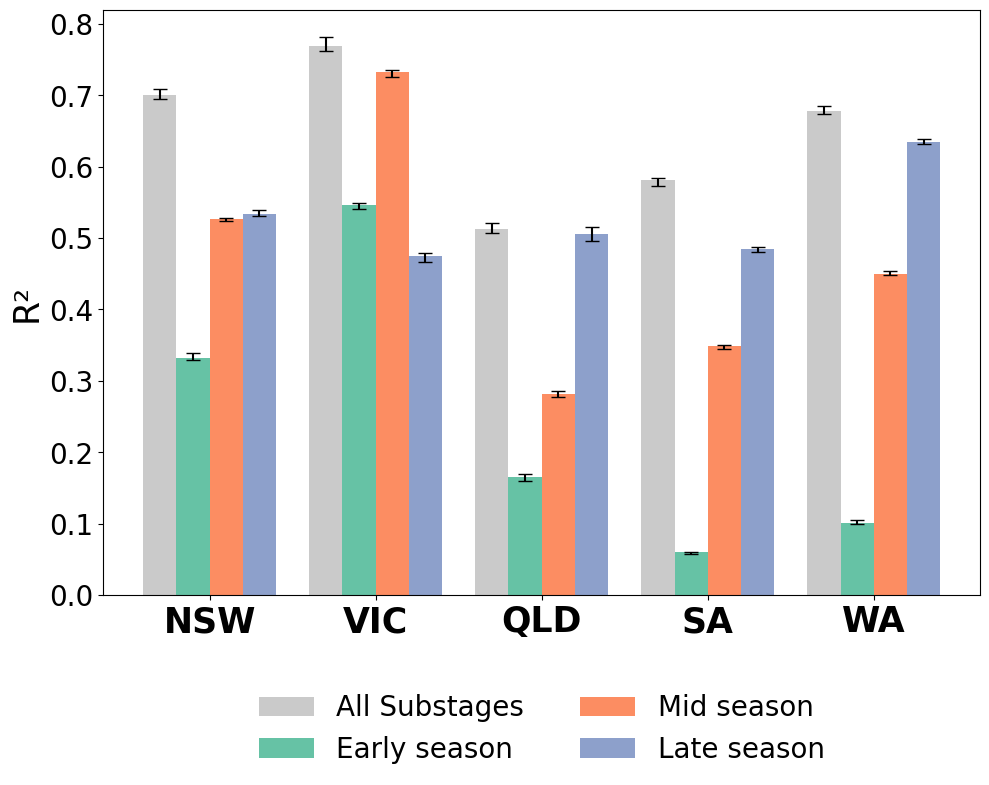

In [30]:
# --- Compute summary stats ---
summary = (
    r2_df.groupby(["state", "stage"])["r2"]
         .agg(["median", "min", "max"])
         .reset_index()
)

summary["lower"] = summary["median"] - summary["min"]
summary["upper"] = summary["max"] - summary["median"]

pivot_median = summary.pivot(index="state", columns="stage", values="median")
pivot_lower  = summary.pivot(index="state", columns="stage", values="lower")
pivot_upper  = summary.pivot(index="state", columns="stage", values="upper")

# --- Enforce consistent state order ---
state_order = ["NSW", "VIC", "QLD", "SA", "WA"]
pivot_median = pivot_median.reindex(state_order)
pivot_lower  = pivot_lower.reindex(state_order)
pivot_upper  = pivot_upper.reindex(state_order)

# --- Stage order (matching your desired order) ---
stage_order = ["all_substages", "planting_season_only", "mid_season_only", "harvest_season_only"]
pivot_median = pivot_median[stage_order]
pivot_lower  = pivot_lower[stage_order]
pivot_upper  = pivot_upper[stage_order]

# --- Colors and labels ---
# color_map = {
#     "all_substages":         "#465EE7",  # blue
#     "planting_season_only":  "#9B59B6",  # purple
#     "mid_season_only":       "#B8B4D9",  # light purple
#     "harvest_season_only":   "#E28101",  # orange
# }

color_map = {
    "all_substages":         "#cacaca",  # navy blue
    "planting_season_only":  "#66c2a5",  # periwinkle blue
    "mid_season_only":       "#fc8d62",  # medium purple
    "harvest_season_only":   "#8da0cb",  # light lilac
}

stage_dict = {
    "all_substages":         "All Substages",
    "planting_season_only":  "Early season",
    "mid_season_only":       "Mid season",
    "harvest_season_only":   "Late season",
}

# --- Plotting ---
states = pivot_median.index
x = np.arange(len(states))
width = 0.8 / len(stage_order)   # same grouped-bar spacing as your other plot

plt.figure(figsize=(10,8))

for i, stage in enumerate(stage_order):
    plt.bar(
        x + (i - len(stage_order)/2) * width + width/2,   # centered bars
        pivot_median[stage],
        width=width,
        label=stage_dict[stage],
        yerr=[pivot_lower[stage], pivot_upper[stage]],
        capsize=5,
        color=color_map[stage],
    )

# --- Axes formatting (matching your style) ---
plt.xticks(x, states, fontsize=25, fontweight="bold")
plt.ylabel("R²", fontsize=25)
plt.yticks(fontsize=20)

# --- Legend below the plot (same as your variables plot) ---
plt.legend(
    fontsize=20,
    bbox_to_anchor=(0.5, -0.15),
    loc="upper center",
    ncol=2,
    frameon=False,
    borderaxespad=0
)

plt.tight_layout()
plt.show()


In [31]:
states = ["NSW", "VIC", "QLD", "SA", "WA"]
summaries = {}
import_datadir = '/g/data/w97/mg5624/ABS_project/yield_model_analytics/variable_importance_scores/'
for state in states:
    df = pd.read_csv(f"{import_datadir}/extremes_only/all_substages/RandomForestRegressor_{state}_permutation_var_import_20agland_norm.csv")   # adjust filename pattern
    
    # Compute stats across seeds (rows)
    mean_imp = df.mean(axis=0)
    min_imp  = df.min(axis=0)
    max_imp  = df.max(axis=0)
    
    summary = pd.DataFrame({
        "mean": mean_imp,
        "min": min_imp,
        "max": max_imp
    })
    
    summary["lower"] = summary["mean"] - summary["min"]
    summary["upper"] = summary["max"] - summary["mean"]
    
    # Sort and keep top 10
    summary = summary.sort_values("mean", ascending=False)#.head(10)
    
    summaries[state] = summary

In [32]:
import re

def transform_name(name):
    stage_map = {
        'growing_seas': '',
        'harvest_seas': 'Late Season',
        'planting_seas': 'Early Season',
        'mid_seas': 'Mid Season'
    }
    # Pattern: stage_var_sum
    m = re.match(r'^(growing_seas|harvest_seas|planting_seas|mid_seas)_(.+?)_(sum|intensity_mean|mean)$', name)
    if not m:
        return name  # leave unchanged if it doesn't match the pattern
    
    stage, var, suffix = m.groups()
    new_stage = stage_map[stage]
    var = var.replace('_', ' ')
    
    if suffix == 'sum':
        return f"{new_stage} No. of {var} days"
    elif suffix == 'intensity_mean':
        return f"{new_stage} {var} intensity"
    elif suffix == 'mean':
        return f"{new_stage} {var} mean"

def find_top3_predictors_per_state(variables, stages):
    states = ["NSW", "VIC", "QLD", "SA", "WA"]

    top3_list = []

    for state in states:
        df = pd.read_csv(f"{import_datadir}{variables}/{stages}/RandomForestRegressor_{state}_permutation_var_import_20agland_norm.csv")   # adjust filename pattern
        
        # Compute stats across seeds
        mean_imp = df.mean(axis=0)
        min_imp  = df.min(axis=0)
        max_imp  = df.max(axis=0)
        
        summary = pd.DataFrame({
            "predictor": mean_imp.index,
            "mean": mean_imp.values,
            "min": min_imp.values,
            "max": max_imp.values
        })
        
        summary["lower"] = summary["mean"] - summary["min"]
        summary["upper"] = summary["max"] - summary["mean"]
        summary["state"] = state
        
        # Select top 3 predictors
        summary = summary.sort_values("mean", ascending=False).head(3)
        summary['predictor'] = summary['predictor'].apply(transform_name)

        top3_list.append(summary)

    # Combine all states
    top3 = pd.concat(top3_list, ignore_index=True)
    return top3

In [33]:
def plot_top3_predictors(top3):

    # --- Clean predictor names ---
    top3["predictor"] = top3["predictor"].str.strip()

    # --- Extract season + variable ---
    # Assumes format: "{season} {variable name...}"
    top3["season"] = top3["predictor"].str.split().str[0].str.lower()

    # Remove the leading "{season} Season " prefix
    top3["variable"] = (
        top3["predictor"]
        .str.replace(r"^(Early|Mid|Late)\s+Season\s+", "", regex=True)
    )

    # --- Color map by variable ---
    var_import_color_map = {
        "No. of 180 day precip drought days": "#F38B04",  # light golden
        "180 day precip drought intensity":   "#EEBC32",  # amber
        "No. of heatwave days":               "#EC9C91",  # light red
        "heatwave intensity":                 "#B60101",  # deep red
    }

    # --- Hatch map by season ---
    hatch_map = {
        "early": "///",
        "mid": "...",
        "late": "",        # plain
    }
    print(top3.head())
    # Assign colors + hatches
    top3["color"] = top3["variable"].map(var_import_color_map)
    top3["hatch"] = top3["season"].map(hatch_map)

    # --- Sort within each state ---
    top3 = top3.sort_values(["state", "mean"], ascending=[True, False])

    # --- Build y positions (your original logic preserved) ---
    y_positions = {}
    state_positions = {}
    labels = []

    y = 3 * len(states) + 3
    for state in states:
        subset = top3[top3["state"] == state].sort_values("mean", ascending=False)
        n = len(subset)

        state_positions[state] = y + (n - 1) / 2 - 0.4

        for idx, row in subset.iterrows():
            y_positions[idx] = y
            labels.append(row["predictor"])
            y -= 1

        y -= 1.5

    top3["y"] = top3.index.map(y_positions)

    # --- Plot ---
    plt.figure(figsize=(12, 8))
    ax = plt.gca()
    for _, row in top3.iterrows():
        ax.barh(
            row["y"],
            row["mean"],
            xerr=[[row["lower"]], [row["upper"]]],
            capsize=5,
            color=row["color"],
            hatch=row["hatch"],
            height=1.0,
            edgecolor="black",
            linewidth=0.8
        )

        # plt.barh(
        #     top3["y"],
        #     top3["mean"],
        #     xerr=[top3["lower"], top3["upper"]],
        #     capsize=5,
        #     color="steelblue",
        #     edgecolor="black"
        # )

    plt.xlabel("Feature importance", fontsize=25)
    plt.xticks(fontsize=20)
    plt.yticks([])

    # --- State labels on the left ---
    xmin, xmax = ax.get_xlim()
    x_label = xmin - 0.005 * (xmax - xmin)
    y_offset = -1.5

    for state in states:
        plt.text(
            x_label,
            state_positions[state] + y_offset,
            state,
            va="center",
            ha="right",
            fontsize=25,
            fontweight="bold",
            rotation=90,
            transform=ax.transData,
        )

    from matplotlib.patches import Patch, FancyBboxPatch
    import matplotlib.transforms as mtransforms

    fig = plt.gcf()
    patch_w, patch_h = 0.05, 0.025  # patch size in figure fraction

    def draw_legend_entry(x, y, pkw, label):
        patch = FancyBboxPatch((x, y), patch_w, patch_h,
                                transform=fig.transFigure,
                                boxstyle="square,pad=0",
                                clip_on=False, **pkw)
        fig.add_artist(patch)
        fig.text(x + patch_w + 0.01, y + patch_h / 2, label,
                 va="center", fontsize=20, transform=fig.transFigure)

    # --- Variable legend: 2 columns (drought / heatwave) x 2 rows (days / intensity) ---
    var_col1 = [
        (dict(facecolor="#F38B04", edgecolor="none"), "Precipitation drought days"),
        (dict(facecolor="#EEBC32", edgecolor="none"), "Precipitation drought intensity"),
    ]
    var_col2 = [
        (dict(facecolor="#EC9C91", edgecolor="none"), "Heatwave days"),
        (dict(facecolor="#B60101", edgecolor="none"), "Heatwave intensity"),
    ]
    var_col_x = [0.0, 0.42]   # x position of each variable column, figure fraction
    var_row_y = [0.10, 0.06]  # y position of row 1 (days) and row 2 (intensity)

    for col_entries, x in zip([var_col1, var_col2], var_col_x):
        for row, (pkw, label) in zip(var_row_y, col_entries):
            draw_legend_entry(x, row, pkw, label)

    # --- Season legend: single horizontal row below the variable grid ---
    season_row = [
        (dict(facecolor="white", edgecolor="black", hatch="///"), "Early season"),
        (dict(facecolor="white", edgecolor="black", hatch="..."), "Mid season"),
        (dict(facecolor="white", edgecolor="black", hatch=""),    "Late season"),
    ]
    season_x = [0.0, 0.28, 0.56]  # x position of each season entry, figure fraction
    season_y = 0.0                # below the variable rows

    for x, (pkw, label) in zip(season_x, season_row):
        draw_legend_entry(x, season_y, pkw, label)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.24)
    plt.show()

                                        predictor      mean       min  \
0                  Late Season heatwave intensity  0.085480  0.080659   
1                   Mid Season heatwave intensity  0.064774  0.055195   
2  Late Season No. of 180 day precip drought days  0.059405  0.051793   
3  Late Season No. of 180 day precip drought days  0.069728  0.053623   
4    Late Season 180 day precip drought intensity  0.067965  0.060976   

        max     lower     upper state season  \
0  0.092540  0.004821  0.007060   NSW   late   
1  0.073670  0.009579  0.008896   NSW    mid   
2  0.076762  0.007613  0.017356   NSW   late   
3  0.079147  0.016105  0.009419   VIC   late   
4  0.079047  0.006989  0.011082   VIC   late   

                             variable  
0                  heatwave intensity  
1                  heatwave intensity  
2  No. of 180 day precip drought days  
3  No. of 180 day precip drought days  
4    180 day precip drought intensity  


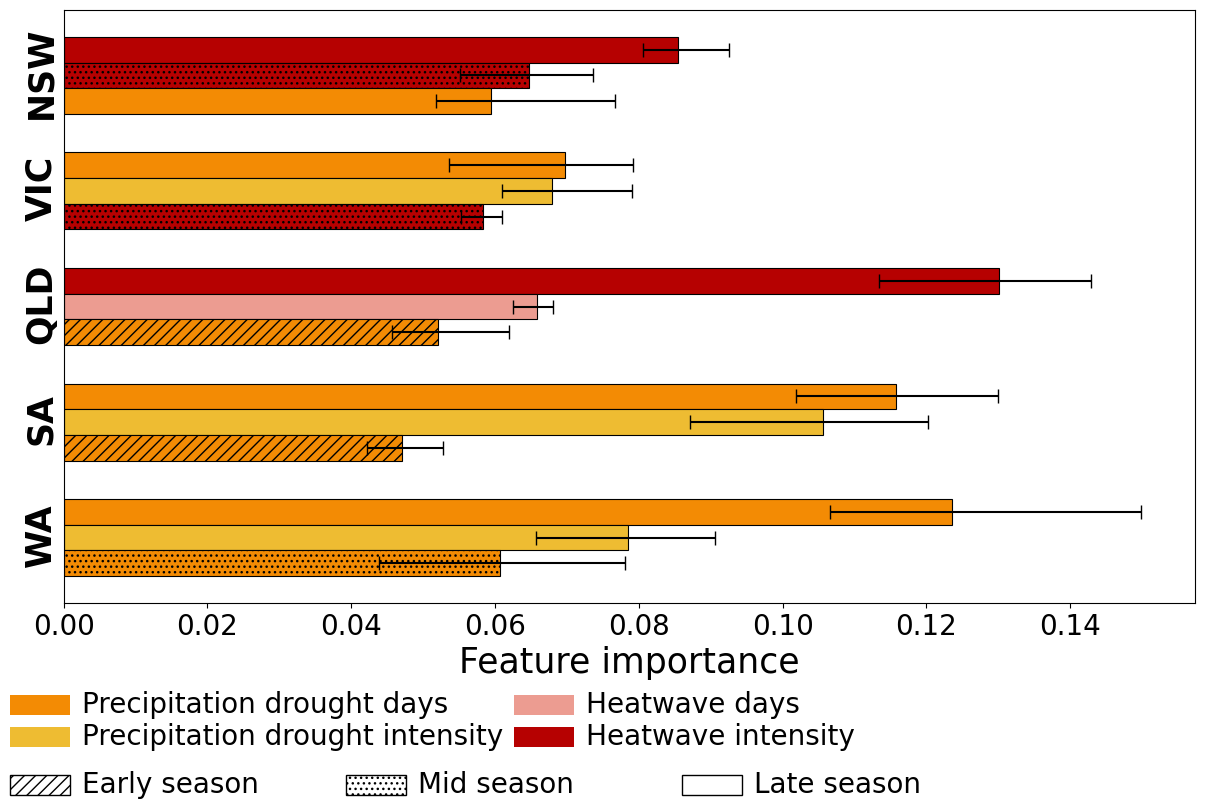

In [34]:
top3_all = find_top3_predictors_per_state('extremes_only', 'all_substages')
plot_top3_predictors(top3_all)

## Yield Trend Comparison

### Load ABS True Yield

In [35]:
from sklearn.preprocessing import StandardScaler
ABS_yield_path = f'{datadir}yield_model_analytics/performance_scores/state_aggregated/all_temp_and_hyd/full_season_only/'
dfs = []
for state in ['AUS', 'NSW', 'QLD', 'VIC', 'SA', 'WA']:
    ABS_yield_file = ABS_yield_path + f'RandomForestRegressor_{state}_predicted_vs_true_yield_yearsplit_20agland_norm.csv'
    ABS_yield = pd.read_csv(ABS_yield_file)
    ABS_yield = ABS_yield[ABS_yield['seed']==0][['year', 'True']]
    ref_period = ABS_yield[ABS_yield['year'] <= 2017]
    scaler = StandardScaler()
    scaler.fit(ref_period[['True']])
    ABS_yield['True'] = scaler.transform(ABS_yield[['True']])
    ABS_yield = ABS_yield.rename(columns={'True': state})
    dfs.append(ABS_yield)

# Merge all on 'year'
ABS_df = dfs[0]
for df in dfs[1:]:
    ABS_df = ABS_df.merge(df, on='year')

### Load 20th Century Crop Yield

In [36]:
twentieth_cent_data_path = f'{datadir}twentieth_cent_crop/'
twent_cent_df = pd.read_csv(twentieth_cent_data_path + 'aus_data_sorted.csv', index_col=0)
twent_cent_df = twent_cent_df[twent_cent_df['Year'] > 1969]
twent_cent_df = twent_cent_df[twent_cent_df['Year'] < 2018]
twent_cent_df = twent_cent_df.rename(columns={'Year':'year'})
twent_cent_df['AUS'] = twent_cent_df[['NSW', 'QLD', 'SA', 'VIC', 'WA']].mean(axis=1)
states = ['AUS', 'NSW', 'QLD', 'SA', 'VIC', 'WA']

# Fit scaler on 2001-2017 period only
ref_period = twent_cent_df[(twent_cent_df['year'] >= 2001) & (twent_cent_df['year'] <= 2017)]
scaler = StandardScaler()
scaler.fit(ref_period[states])

# Apply to full dataframe
twent_cent_df[states] = scaler.transform(twent_cent_df[states])

### Load Modelled Yield

In [37]:
modelled_yield_path = f'{datadir}yield_model_analytics/modelled_yield/past_yield/all_states_modelled_annual_avg_yield.csv'
modelled_yield_df = pd.read_csv(modelled_yield_path)
modelled_yield = modelled_yield_df[(modelled_yield_df['year'] >= 1970) & (modelled_yield_df['year'] <= 2020)]
modelled_yield = modelled_yield.pivot(index='year', columns='state', values='predicted_yield').reset_index()

ref_period = modelled_yield[(modelled_yield['year'] >= 2001) & (modelled_yield['year'] <= 2017)]
scaler = StandardScaler()
scaler.fit(ref_period[states])

# Apply to full dataframe
modelled_yield[states] = scaler.transform(modelled_yield[states])

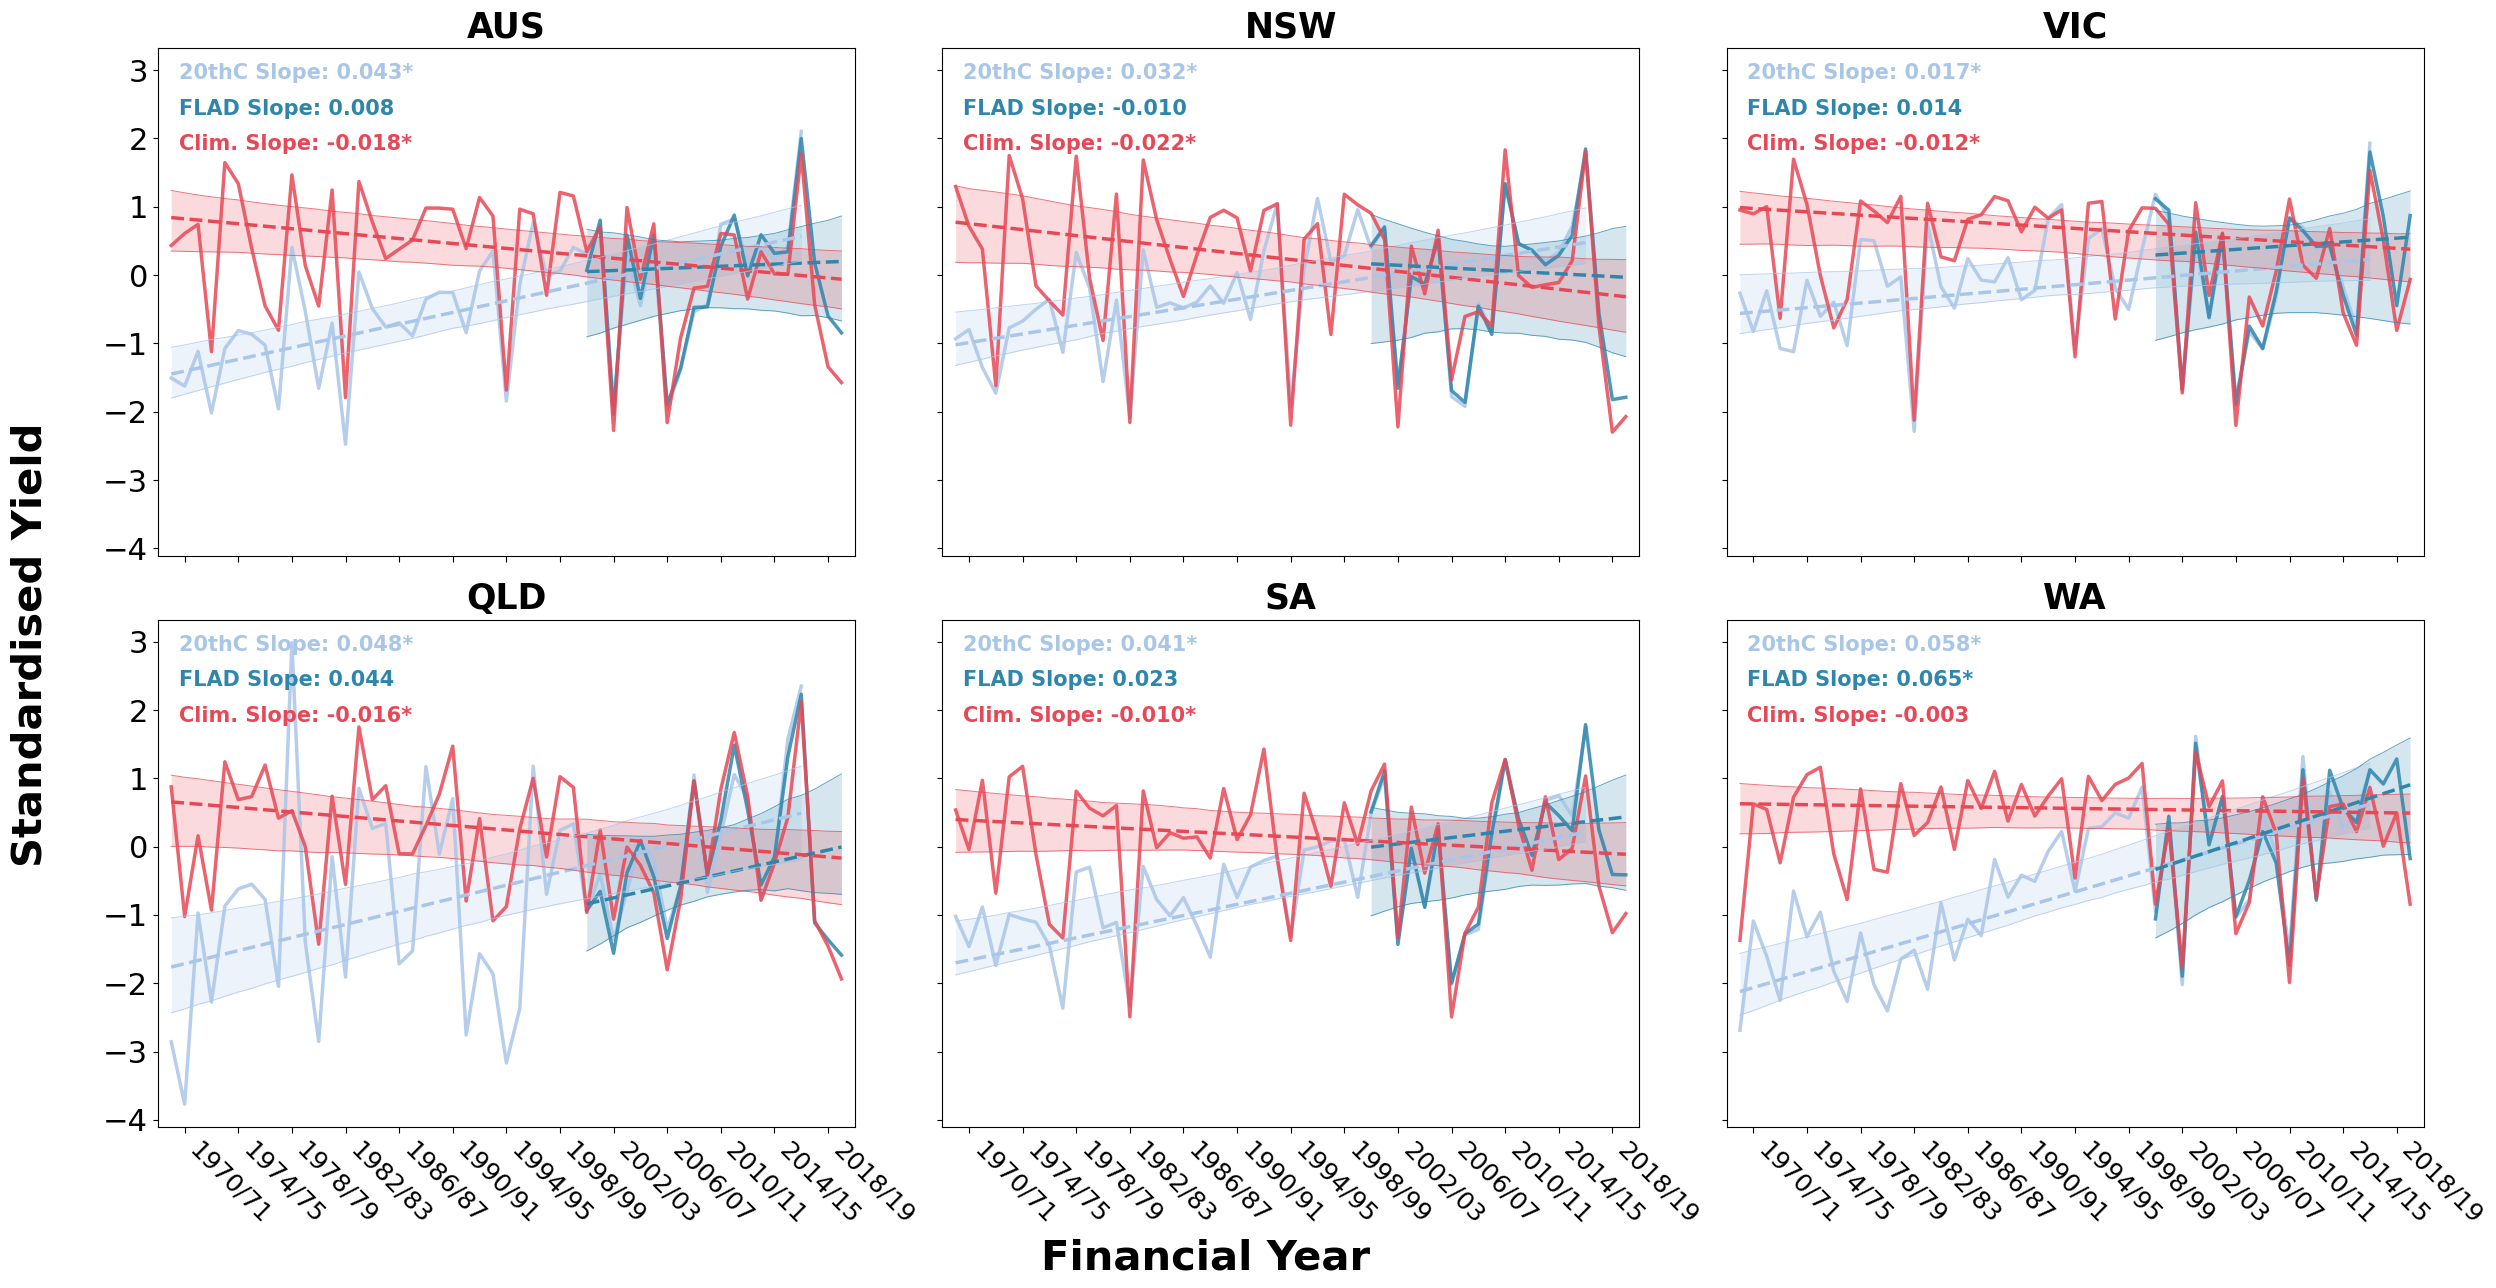

In [38]:
import pymannkendall as mk

# Palette
col_twent = "#A9C6E8"   # light blue - twentieth century obs
col_abs   = "#2E86AB"   # blue - obs (FLAD/ABS)
col_model = "#E84855"   # reddish - modelled


def bootstrap_slope_intercept(y, n_boot=1000, random_state=None):
    """Residual bootstrap of Yue-Wang Theil-Sen slope/intercept for a 1D array."""
    rng = np.random.default_rng(random_state)
    n = len(y)
    x = np.arange(n)

    base = mk.yue_wang_modification_test(y)
    slope0, intercept0 = base.slope, base.intercept
    fitted = slope0 * x + intercept0
    residuals = y - fitted

    boot_slopes = np.empty(n_boot)
    boot_intercepts = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_boot = fitted + residuals[idx]
        res = mk.yue_wang_modification_test(y_boot)
        boot_slopes[i] = res.slope
        boot_intercepts[i] = res.intercept

    return slope0, intercept0, base.trend, boot_slopes, boot_intercepts


def bootstrap_band(x, slope0, intercept0, boot_slopes, boot_intercepts, ci=95):
    """
    Direct (non-pivoted) bootstrap uncertainty band: evaluate every
    bootstrapped (slope, intercept) line across x, then take percentiles
    at each x. Because slope and intercept are correlated across
    bootstrap draws, this band is not perfectly linear/fan-shaped -- it
    can flex slightly along x, unlike a band pivoted through one fixed point.
    """
    trendline = slope0 * x + intercept0
    lo_pct, hi_pct = (100 - ci) / 2, 100 - (100 - ci) / 2
    boot_lines = boot_slopes[:, None] * x[None, :] + boot_intercepts[:, None]
    lower = np.percentile(boot_lines, lo_pct, axis=0)
    upper = np.percentile(boot_lines, hi_pct, axis=0)
    return trendline, lower, upper

states = ['AUS', 'NSW', 'VIC', 'QLD', 'SA', 'WA']

n_boot = 1000
full_years = np.arange(1971, 2021)

fig, axes = plt.subplots(2, 3, figsize=(26, 13), sharex=True, sharey=True)
axes = axes.flatten()

for ax, state in zip(axes, states):
    abs_vals = ABS_df[state].values
    twent_vals = twent_cent_df[state].values
    model_vals = modelled_yield[state].values

    twent_years = twent_cent_df['year']
    abs_years = ABS_df['year']
    model_years = modelled_yield['year']

    tick_years = full_years[::4]
    tick_labels = [f"{y-1}/{str(y)[-2:]}" for y in tick_years]

    slope_twent, intercept_twent, trend_twent, bs_twent, bi_twent = bootstrap_slope_intercept(
        twent_vals, n_boot=n_boot, random_state=42)
    slope_abs, intercept_abs, trend_abs, bs_abs, bi_abs = bootstrap_slope_intercept(
        abs_vals, n_boot=n_boot, random_state=42)
    slope_model, intercept_model, trend_model, bs_model, bi_model = bootstrap_slope_intercept(
        model_vals, n_boot=n_boot, random_state=42)

    sig_twent = trend_twent != "no trend"
    sig_abs = trend_abs != "no trend"
    sig_model = trend_model != "no trend"

    x_twent = np.arange(len(twent_years))
    x_abs = np.arange(len(abs_years))
    x_model = np.arange(len(model_years))

    twent_trend, twent_lower, twent_upper = bootstrap_band(x_twent, slope_twent, intercept_twent, bs_twent, bi_twent)
    abs_trend, abs_lower, abs_upper = bootstrap_band(x_abs, slope_abs, intercept_abs, bs_abs, bi_abs)
    model_trend, model_lower, model_upper = bootstrap_band(x_model, slope_model, intercept_model, bs_model, bi_model)

    # observed series
    ax.plot(twent_years, twent_vals, color=col_twent, linewidth=2.5, alpha=0.85)
    ax.plot(abs_years, abs_vals, color=col_abs, linewidth=2.5, alpha=0.85)
    ax.plot(model_years, model_vals, color=col_model, linewidth=2.5, alpha=0.85)

    # trendlines
    ax.plot(twent_years, twent_trend, color=col_twent, linewidth=2.5, linestyle="--")
    ax.plot(abs_years, abs_trend, color=col_abs, linewidth=2.5, linestyle="--")
    ax.plot(model_years, model_trend, color=col_model, linewidth=2.5, linestyle="--")

    # bootstrap uncertainty bands (curved, direct percentile of bootstrapped lines)
    ax.fill_between(twent_years, twent_lower, twent_upper, color=col_twent, alpha=0.2, linewidth=0)
    ax.fill_between(abs_years, abs_lower, abs_upper, color=col_abs, alpha=0.2, linewidth=0)
    ax.fill_between(model_years, model_lower, model_upper, color=col_model, alpha=0.2, linewidth=0)

    # thin border lines on the bands
    ax.plot(twent_years, twent_lower, color=col_twent, linewidth=0.7, alpha=0.75)
    ax.plot(twent_years, twent_upper, color=col_twent, linewidth=0.7, alpha=0.75)
    ax.plot(abs_years, abs_lower, color=col_abs, linewidth=0.7, alpha=0.75)
    ax.plot(abs_years, abs_upper, color=col_abs, linewidth=0.7, alpha=0.75)
    ax.plot(model_years, model_lower, color=col_model, linewidth=0.7, alpha=0.75)
    ax.plot(model_years, model_upper, color=col_model, linewidth=0.7, alpha=0.75)

    sig_marker_twent = "*" if sig_twent else ""
    sig_marker_abs = "*" if sig_abs else ""
    sig_marker_model = "*" if sig_model else ""
    text_twent = f"20thC Slope: {slope_twent:.3f}{sig_marker_twent}"
    text_abs = f"FLAD Slope: {slope_abs:.3f}{sig_marker_abs}"
    text_model = f"Clim. Slope: {slope_model:.3f}{sig_marker_model}"

    ax.text(0.03, 0.97, text_twent, color=col_twent,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")
    ax.text(0.03, 0.90, text_abs, color=col_abs,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")
    ax.text(0.03, 0.83, text_model, color=col_model,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")

    ax.set_title(state, fontsize=25, fontweight="bold", pad=8)
    ax.set_xlim(1969, 2021)
    ax.set_xticks(tick_years)
    ax.set_xticklabels(tick_labels, rotation=-45, ha='left', fontsize=18)
    ax.tick_params(axis='y', labelsize=22)
    ax.tick_params(axis='x', which='both', length=4)

fig.text(0.5, 0.02, "Financial Year", ha='center', fontsize=30, fontweight="bold")
fig.text(0.04, 0.5, "Standardised Yield",
         va='center', rotation='vertical', fontsize=30, fontweight="bold")

plt.tight_layout(rect=[0.07, 0.04, 1, 1])
# plt.savefig("/home/claude/publication_style_3series_bootstrap.png", dpi=150, bbox_inches="tight")


### Option 2

In [35]:
twent_cent_to_comb = twent_cent_df[(twent_cent_df['year'] >= 1969) & (twent_cent_df['year'] <= 2000)]
obs_yield = pd.concat([twent_cent_to_comb, ABS_df], ignore_index=True)

scaler = StandardScaler()
scaler.fit(obs_yield[states])
obs_yield[states] = scaler.transform(obs_yield[states])

scaler = StandardScaler()
scaler.fit(modelled_yield[states])
modelled_yield[states] = scaler.transform(modelled_yield[states])

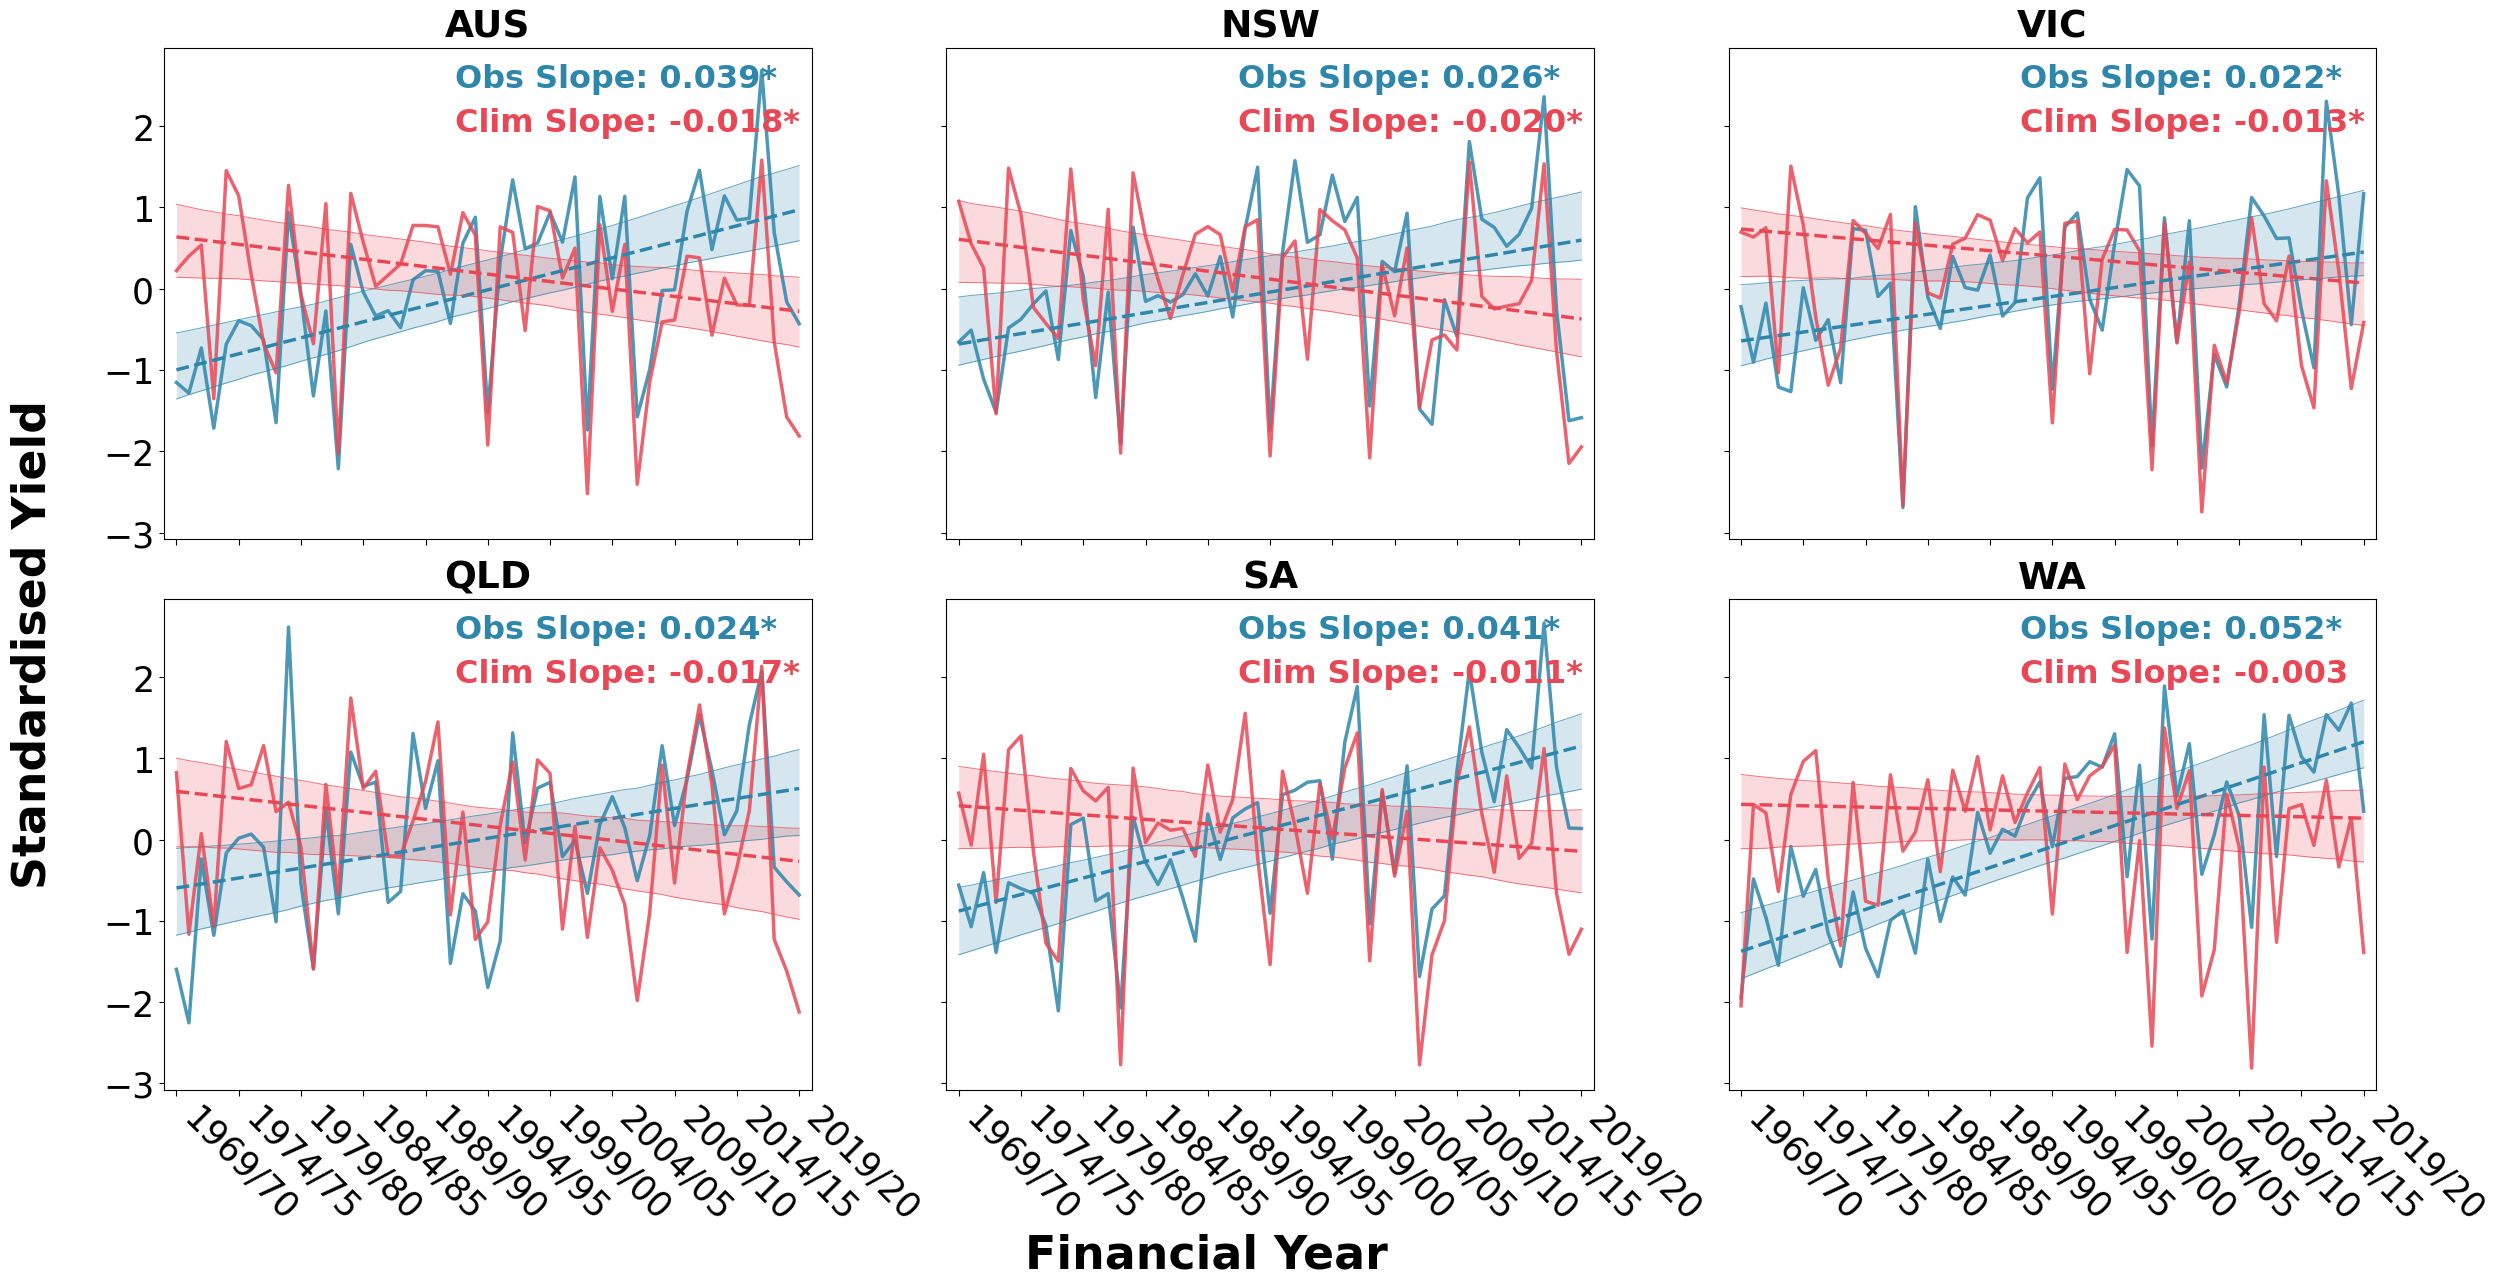

In [36]:
import matplotlib.transforms as mtransforms

col_obs   = "#2E86AB"   # blue - obs (FLAD/ABS)
col_model = "#E84855"   # reddish - modelled

states = ['AUS', 'NSW', 'VIC', 'QLD', 'SA', 'WA']

n_boot = 1000
full_years = np.arange(1970, 2021)

fig, axes = plt.subplots(2, 3, figsize=(26, 13), sharex=True, sharey=True)
axes = axes.flatten()

for ax, state in zip(axes, states):
    obs_yield_annual = obs_yield[obs_yield['year'] >= 1970]
    model_yield_plot_annual = modelled_yield[modelled_yield['year'] >= 1970]

    obs_vals = obs_yield_annual[state].values
    model_vals = model_yield_plot_annual[state].values

    obs_years = obs_yield_annual['year']
    model_years = model_yield_plot_annual['year']

    tick_years = full_years[::5]
    tick_labels = [f"{y-1}/{str(y)[-2:]}" for y in tick_years]

    slope_obs, intercept_obs, trend_obs, bs_obs, bi_obs = bootstrap_slope_intercept(
        obs_vals, n_boot=n_boot, random_state=42)
    slope_model, intercept_model, trend_model, bs_model, bi_model = bootstrap_slope_intercept(
        model_vals, n_boot=n_boot, random_state=42)

    sig_obs = trend_obs != "no trend"
    sig_model = trend_model != "no trend"

    x_obs = np.arange(len(obs_years))
    x_model = np.arange(len(model_years))

    obs_trend, obs_lower, obs_upper = bootstrap_band(x_obs, slope_obs, intercept_obs, bs_obs, bi_obs)
    model_trend, model_lower, model_upper = bootstrap_band(x_model, slope_model, intercept_model, bs_model, bi_model)

    # observed series
    ax.plot(obs_years, obs_vals, color=col_obs, linewidth=2.5, alpha=0.85)
    ax.plot(model_years, model_vals, color=col_model, linewidth=2.5, alpha=0.85)

    # trendlines
    ax.plot(obs_years, obs_trend, color=col_obs, linewidth=2.5, linestyle="--")
    ax.plot(model_years, model_trend, color=col_model, linewidth=2.5, linestyle="--")

    # bootstrap uncertainty bands (curved, direct percentile of bootstrapped lines)
    ax.fill_between(obs_years, obs_lower, obs_upper, color=col_obs, alpha=0.2, linewidth=0)
    ax.fill_between(model_years, model_lower, model_upper, color=col_model, alpha=0.2, linewidth=0)

    # thin border lines on the bands
    ax.plot(obs_years, obs_lower, color=col_obs, linewidth=0.7, alpha=0.75)
    ax.plot(obs_years, obs_upper, color=col_obs, linewidth=0.7, alpha=0.75)
    ax.plot(model_years, model_lower, color=col_model, linewidth=0.7, alpha=0.75)
    ax.plot(model_years, model_upper, color=col_model, linewidth=0.7, alpha=0.75)

    sig_marker_obs = "*" if sig_obs else ""
    sig_marker_model = "*" if sig_model else ""
    text_obs = f"Obs Slope: {slope_obs:.3f}{sig_marker_obs}"
    text_model = f"Clim Slope: {slope_model:.3f}{sig_marker_model}"

    ax.text(0.45, 0.97, text_obs, color=col_obs,
            fontsize=23, va="top", ha="left", transform=ax.transAxes, fontweight="bold")
    ax.text(0.45, 0.88, text_model, color=col_model,
            fontsize=23, va="top", ha="left", transform=ax.transAxes, fontweight="bold")

    ax.set_title(state, fontsize=27, fontweight="bold", pad=8)
    ax.set_xlim(1969, 2021)
    ax.set_xticks(tick_years)
    ax.set_xticklabels(tick_labels, rotation=-45, ha='left', fontsize=25)
    offset = mtransforms.ScaledTranslation(-0.1, 0, fig.dpi_scale_trans)
    for label in ax.get_xticklabels():
        label.set_transform(label.get_transform() + offset)
    ax.tick_params(axis='y', labelsize=25)
    ax.tick_params(axis='x', which='both', length=4)

fig.text(0.5, 0.02, "Financial Year", ha='center', fontsize=33, fontweight="bold")
fig.text(0.04, 0.5, "Standardised Yield",
         va='center', rotation='vertical', fontsize=33, fontweight="bold")

plt.tight_layout(rect=[0.07, 0.04, 1, 1])

In [ ]:
import pymannkendall as mk

# Palette
col_twent = "#A9C6E8"   # light blue - twentieth century obs
col_abs   = "#2E86AB"   # blue - obs (FLAD/ABS)
col_model = "#E84855"   # reddish - modelled


def bootstrap_slope_intercept(y, n_boot=1000, random_state=None):
    """Residual bootstrap of Yue-Wang Theil-Sen slope/intercept for a 1D array."""
    rng = np.random.default_rng(random_state)
    n = len(y)
    x = np.arange(n)

    base = mk.yue_wang_modification_test(y)
    slope0, intercept0 = base.slope, base.intercept
    fitted = slope0 * x + intercept0
    residuals = y - fitted

    boot_slopes = np.empty(n_boot)
    boot_intercepts = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_boot = fitted + residuals[idx]
        res = mk.yue_wang_modification_test(y_boot)
        boot_slopes[i] = res.slope
        boot_intercepts[i] = res.intercept

    return slope0, intercept0, base.trend, boot_slopes, boot_intercepts


def bootstrap_band(x, slope0, intercept0, boot_slopes, boot_intercepts, ci=95):
    """
    Direct (non-pivoted) bootstrap uncertainty band: evaluate every
    bootstrapped (slope, intercept) line across x, then take percentiles
    at each x. Because slope and intercept are correlated across
    bootstrap draws, this band is not perfectly linear/fan-shaped -- it
    can flex slightly along x, unlike a band pivoted through one fixed point.
    """
    trendline = slope0 * x + intercept0
    lo_pct, hi_pct = (100 - ci) / 2, 100 - (100 - ci) / 2
    boot_lines = boot_slopes[:, None] * x[None, :] + boot_intercepts[:, None]
    lower = np.percentile(boot_lines, lo_pct, axis=0)
    upper = np.percentile(boot_lines, hi_pct, axis=0)
    return trendline, lower, upper

states = ['AUS', 'NSW', 'VIC', 'QLD', 'SA', 'WA']

n_boot = 1000
full_years = np.arange(1971, 2021)

fig, axes = plt.subplots(2, 3, figsize=(26, 13), sharex=True, sharey=True)
axes = axes.flatten()

for ax, state in zip(axes, states):
    abs_vals = ABS_df[state].values
    twent_vals = twent_cent_df[state].values
    model_vals = modelled_yield[state].values

    twent_years = twent_cent_df['year']
    abs_years = ABS_df['year']
    model_years = modelled_yield['year']

    tick_years = full_years[::4]
    tick_labels = [f"{y-1}/{str(y)[-2:]}" for y in tick_years]

    slope_twent, intercept_twent, trend_twent, bs_twent, bi_twent = bootstrap_slope_intercept(
        twent_vals, n_boot=n_boot, random_state=42)
    slope_abs, intercept_abs, trend_abs, bs_abs, bi_abs = bootstrap_slope_intercept(
        abs_vals, n_boot=n_boot, random_state=42)
    slope_model, intercept_model, trend_model, bs_model, bi_model = bootstrap_slope_intercept(
        model_vals, n_boot=n_boot, random_state=42)

    sig_twent = trend_twent != "no trend"
    sig_abs = trend_abs != "no trend"
    sig_model = trend_model != "no trend"

    x_twent = np.arange(len(twent_years))
    x_abs = np.arange(len(abs_years))
    x_model = np.arange(len(model_years))

    twent_trend, twent_lower, twent_upper = bootstrap_band(x_twent, slope_twent, intercept_twent, bs_twent, bi_twent)
    abs_trend, abs_lower, abs_upper = bootstrap_band(x_abs, slope_abs, intercept_abs, bs_abs, bi_abs)
    model_trend, model_lower, model_upper = bootstrap_band(x_model, slope_model, intercept_model, bs_model, bi_model)

    # observed series
    ax.plot(twent_years, twent_vals, color=col_twent, linewidth=2.5, alpha=0.85)
    ax.plot(abs_years, abs_vals, color=col_abs, linewidth=2.5, alpha=0.85)
    ax.plot(model_years, model_vals, color=col_model, linewidth=2.5, alpha=0.85)

    # trendlines
    ax.plot(twent_years, twent_trend, color=col_twent, linewidth=2.5, linestyle="--")
    ax.plot(abs_years, abs_trend, color=col_abs, linewidth=2.5, linestyle="--")
    ax.plot(model_years, model_trend, color=col_model, linewidth=2.5, linestyle="--")

    # bootstrap uncertainty bands (curved, direct percentile of bootstrapped lines)
    ax.fill_between(twent_years, twent_lower, twent_upper, color=col_twent, alpha=0.2, linewidth=0)
    ax.fill_between(abs_years, abs_lower, abs_upper, color=col_abs, alpha=0.2, linewidth=0)
    ax.fill_between(model_years, model_lower, model_upper, color=col_model, alpha=0.2, linewidth=0)

    # thin border lines on the bands
    ax.plot(twent_years, twent_lower, color=col_twent, linewidth=0.7, alpha=0.75)
    ax.plot(twent_years, twent_upper, color=col_twent, linewidth=0.7, alpha=0.75)
    ax.plot(abs_years, abs_lower, color=col_abs, linewidth=0.7, alpha=0.75)
    ax.plot(abs_years, abs_upper, color=col_abs, linewidth=0.7, alpha=0.75)
    ax.plot(model_years, model_lower, color=col_model, linewidth=0.7, alpha=0.75)
    ax.plot(model_years, model_upper, color=col_model, linewidth=0.7, alpha=0.75)

    sig_marker_twent = "*" if sig_twent else ""
    sig_marker_abs = "*" if sig_abs else ""
    sig_marker_model = "*" if sig_model else ""
    text_twent = f"20thC Slope: {slope_twent:.3f}{sig_marker_twent}"
    text_abs = f"FLAD Slope: {slope_abs:.3f}{sig_marker_abs}"
    text_model = f"Model Slope: {slope_model:.3f}{sig_marker_model}"

    ax.text(0.03, 0.97, text_twent, color=col_twent,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")
    ax.text(0.03, 0.90, text_abs, color=col_abs,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")
    ax.text(0.03, 0.83, text_model, color=col_model,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")

    ax.set_title(state, fontsize=25, fontweight="bold", pad=8)
    ax.set_xlim(1969, 2021)
    ax.set_xticks(tick_years)
    ax.set_xticklabels(tick_labels, rotation=-45, ha='left', fontsize=18)
    ax.tick_params(axis='y', labelsize=22)
    ax.tick_params(axis='x', which='both', length=4)

fig.text(0.5, 0.02, "Financial Year", ha='center', fontsize=30, fontweight="bold")
fig.text(0.04, 0.5, "Standardised Yield",
         va='center', rotation='vertical', fontsize=30, fontweight="bold")

plt.tight_layout(rect=[0.07, 0.04, 1, 1])
# plt.savefig("/home/claude/publication_style_3series_bootstrap.png", dpi=150, bbox_inches="tight")
